In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff

sns.set(style="whitegrid")
#Standardisation
from sklearn.preprocessing import StandardScaler
#ACP
from sklearn.decomposition import PCA
#CAH
from scipy.cluster.hierarchy import dendrogram, linkage
#K-means
from sklearn.cluster import KMeans

In [3]:
donnees_acp=pd.read_csv("..\data_clean\df_ACP.csv")
donnees_acp.head()

,Country,taux_remplissage,nb_colonnes_remplies,ISO3,indicateur_perf_logistique,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,...,Producing Animals/Slaughtered,livestock_production,livestock_stock,livestock_yield_carcass_weight,poultry_price_lcu_t,poultry_export_t,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t
0,Bosnia and Herzegovina,100.0,26,BIH,3.0,21117.283077,-0.483194,3204802.0,49.841,-0.483194,...,43537.0,67007.00,9299.0,1539.0,2263.0,6641.0,29708.0,1268.0,773.0,100.0
1,Switzerland,100.0,26,CHE,4.1,91326.131705,1.159745,8777088.0,74.092,1.159745,...,87825.0,109515.00,13109.0,1247.0,3527.0,1183.0,309.0,612.0,1606.0,184.0
2,Belgium,100.0,26,BEL,4.0,68157.834786,0.581982,11680210.0,98.153,0.581982,...,297794.0,442020.00,53283.0,1484.0,1247.6,121147.0,109384.0,2352.0,9771.0,3460.0
3,Cameroon,100.0,26,CMR,2.1,5188.977509,-1.379629,27632771.0,58.733,-1.379629,...,104117.0,127126.07,51769.0,1221.0,1994436.5,101.0,1039.0,2201.0,1020.0,22.0
4,Canada,100.0,26,CAN,4.0,63578.320195,0.780682,38935934.0,81.752,0.780682,...,789394.0,1370800.00,171099.0,1737.0,2893.9,4547.0,31890.0,48895.0,8213.0,22936.0


In [4]:
donnees_acp.columns

Index(['Country', 'taux_remplissage', 'nb_colonnes_remplies', 'ISO3',
       'indicateur_perf_logistique', 'pib_par_hab', 'stab_politique',
       'population', 'tx_urbanisation', 'tarif_douanier_moyen',
       'emissions_agri_pc', 'organic_share', 'hfce_per_capita_usd_const2015',
       'food_balance_export_quantity', 'food_balance_import_quantity',
       'food_balance_production', 'Producing Animals/Slaughtered',
       'livestock_production', 'livestock_stock',
       'livestock_yield_carcass_weight', 'poultry_price_lcu_t',
       'poultry_export_t', 'poultry_import_t', 'cereal_production_t',
       'cereal_import_t', 'cereal_export_t'],
      dtype='object')

In [5]:
# Sélection des colonnes quantitatives pour ACP
cols_acp = [
    'indicateur_perf_logistique',
    'pib_par_hab',
    'stab_politique',
    'population',
    'tx_urbanisation',
    'tarif_douanier_moyen',
    'emissions_agri_pc',
    'organic_share',
    'hfce_per_capita_usd_const2015',
    'food_balance_production',
    'Producing Animals/Slaughtered',
    'livestock_production',
    'livestock_stock',
    'livestock_yield_carcass_weight',
    'poultry_price_lcu_t',
    'poultry_export_t',
    'poultry_import_t',
    'cereal_production_t',
    'cereal_import_t',
    'cereal_export_t'
]

df_acp = donnees_acp[cols_acp].copy()
df_acp.head()

,indicateur_perf_logistique,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,emissions_agri_pc,organic_share,hfce_per_capita_usd_const2015,food_balance_production,Producing Animals/Slaughtered,livestock_production,livestock_stock,livestock_yield_carcass_weight,poultry_price_lcu_t,poultry_export_t,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t
0,3.0,21117.283077,-0.483194,3204802.0,49.841,-0.483194,234.02382,0.11,4506.032565,67.0,43537.0,67007.00,9299.0,1539.0,2263.0,6641.0,29708.0,1268.0,773.0,100.0
1,4.1,91326.131705,1.159745,8777088.0,74.092,1.159745,143.30917,12.38,44877.858320,112.0,87825.0,109515.00,13109.0,1247.0,3527.0,1183.0,309.0,612.0,1606.0,184.0
2,4.0,68157.834786,0.581982,11680210.0,98.153,0.581982,175.23042,7.49,21959.173610,450.0,297794.0,442020.00,53283.0,1484.0,1247.6,121147.0,109384.0,2352.0,9771.0,3460.0
3,2.1,5188.977509,-1.379629,27632771.0,58.733,-1.379629,187.82048,0.02,1093.627768,127.0,104117.0,127126.07,51769.0,1221.0,1994436.5,101.0,1039.0,2201.0,1020.0,22.0
4,4.0,63578.320195,0.780682,38935934.0,81.752,0.780682,872.97530,2.75,26412.766573,1532.0,789394.0,1370800.00,171099.0,1737.0,2893.9,4547.0,31890.0,48895.0,8213.0,22936.0


In [6]:
df_acp.isna().sum()


indicateur_perf_logistique        33
pib_par_hab                        1
stab_politique                     0
population                         0
tx_urbanisation                    0
tarif_douanier_moyen               0
emissions_agri_pc                  1
organic_share                     22
hfce_per_capita_usd_const2015     23
food_balance_production            0
Producing Animals/Slaughtered      3
livestock_production               1
livestock_stock                   11
livestock_yield_carcass_weight     4
poultry_price_lcu_t               32
poultry_export_t                  63
poultry_import_t                   5
cereal_production_t                0
cereal_import_t                    0
cereal_export_t                    0
dtype: int64

In [7]:
# Liste des colonnes à exclure pour l’ACP
cols_exclude_missing = [
    "indicateur_perf_logistique",
    "organic_share",
    "hfce_per_capita_usd_const2015",
    "poultry_price_lcu_t",
    "poultry_export_t",
    "livestock_stock"
]

df_acp=df_acp.drop(columns=cols_exclude_missing)
df_acp.head()

,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,emissions_agri_pc,food_balance_production,Producing Animals/Slaughtered,livestock_production,livestock_yield_carcass_weight,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t
0,21117.283077,-0.483194,3204802.0,49.841,-0.483194,234.02382,67.0,43537.0,67007.00,1539.0,29708.0,1268.0,773.0,100.0
1,91326.131705,1.159745,8777088.0,74.092,1.159745,143.30917,112.0,87825.0,109515.00,1247.0,309.0,612.0,1606.0,184.0
2,68157.834786,0.581982,11680210.0,98.153,0.581982,175.23042,450.0,297794.0,442020.00,1484.0,109384.0,2352.0,9771.0,3460.0
3,5188.977509,-1.379629,27632771.0,58.733,-1.379629,187.82048,127.0,104117.0,127126.07,1221.0,1039.0,2201.0,1020.0,22.0
4,63578.320195,0.780682,38935934.0,81.752,0.780682,872.97530,1532.0,789394.0,1370800.00,1737.0,31890.0,48895.0,8213.0,22936.0


In [8]:
# Vérifier les manquants restants
df_acp.isna().sum()

pib_par_hab                       1
stab_politique                    0
population                        0
tx_urbanisation                   0
tarif_douanier_moyen              0
emissions_agri_pc                 1
food_balance_production           0
Producing Animals/Slaughtered     3
livestock_production              1
livestock_yield_carcass_weight    4
poultry_import_t                  5
cereal_production_t               0
cereal_import_t                   0
cereal_export_t                   0
dtype: int64

In [9]:
#Imputation par la médiane
df_acp = df_acp.fillna(df_acp.median())
df_acp.isna().sum()

pib_par_hab                       0
stab_politique                    0
population                        0
tx_urbanisation                   0
tarif_douanier_moyen              0
emissions_agri_pc                 0
food_balance_production           0
Producing Animals/Slaughtered     0
livestock_production              0
livestock_yield_carcass_weight    0
poultry_import_t                  0
cereal_production_t               0
cereal_import_t                   0
cereal_export_t                   0
dtype: int64

In [10]:
df_acp.describe().T

,count,mean,std,min,25%,50%,75%,max
pib_par_hab,159.0,2.780760e+04,2.747431e+04,1484.241169,7.063487e+03,1.779500e+04,4.152778e+04,1.433819e+05
stab_politique,159.0,-9.745796e-02,8.886330e-01,-2.776898,-6.224928e-01,-9.451321e-02,6.386009e-01,1.321169e+00
population,159.0,4.764677e+07,1.637349e+08,92840.000000,2.929431e+06,1.020317e+07,3.481722e+07,1.425423e+09
tx_urbanisation,159.0,6.075214e+01,2.234090e+01,13.582000,4.375850e+01,6.281800e+01,8.034150e+01,1.000000e+02
tarif_douanier_moyen,159.0,-9.745796e-02,8.886330e-01,-2.776898,-6.224928e-01,-9.451321e-02,6.386009e-01,1.321169e+00
emissions_agri_pc,159.0,3.555031e+02,4.777573e+02,12.802868,1.365873e+02,2.124161e+02,3.479403e+02,3.833415e+03
food_balance_production,159.0,8.651824e+02,2.970840e+03,0.000000,1.900000e+01,1.130000e+02,4.800000e+02,2.523500e+04
Producing Animals/Slaughtered,159.0,4.621329e+05,1.383615e+06,0.000000,1.339350e+04,7.600350e+04,2.828565e+05,1.180265e+07
livestock_production,159.0,7.603203e+05,2.375727e+06,0.000000,1.661562e+04,1.107870e+05,4.332365e+05,1.984124e+07
livestock_yield_carcass_weight,159.0,1.450314e+03,5.578863e+02,550.000000,1.003000e+03,1.460000e+03,1.727500e+03,3.688000e+03


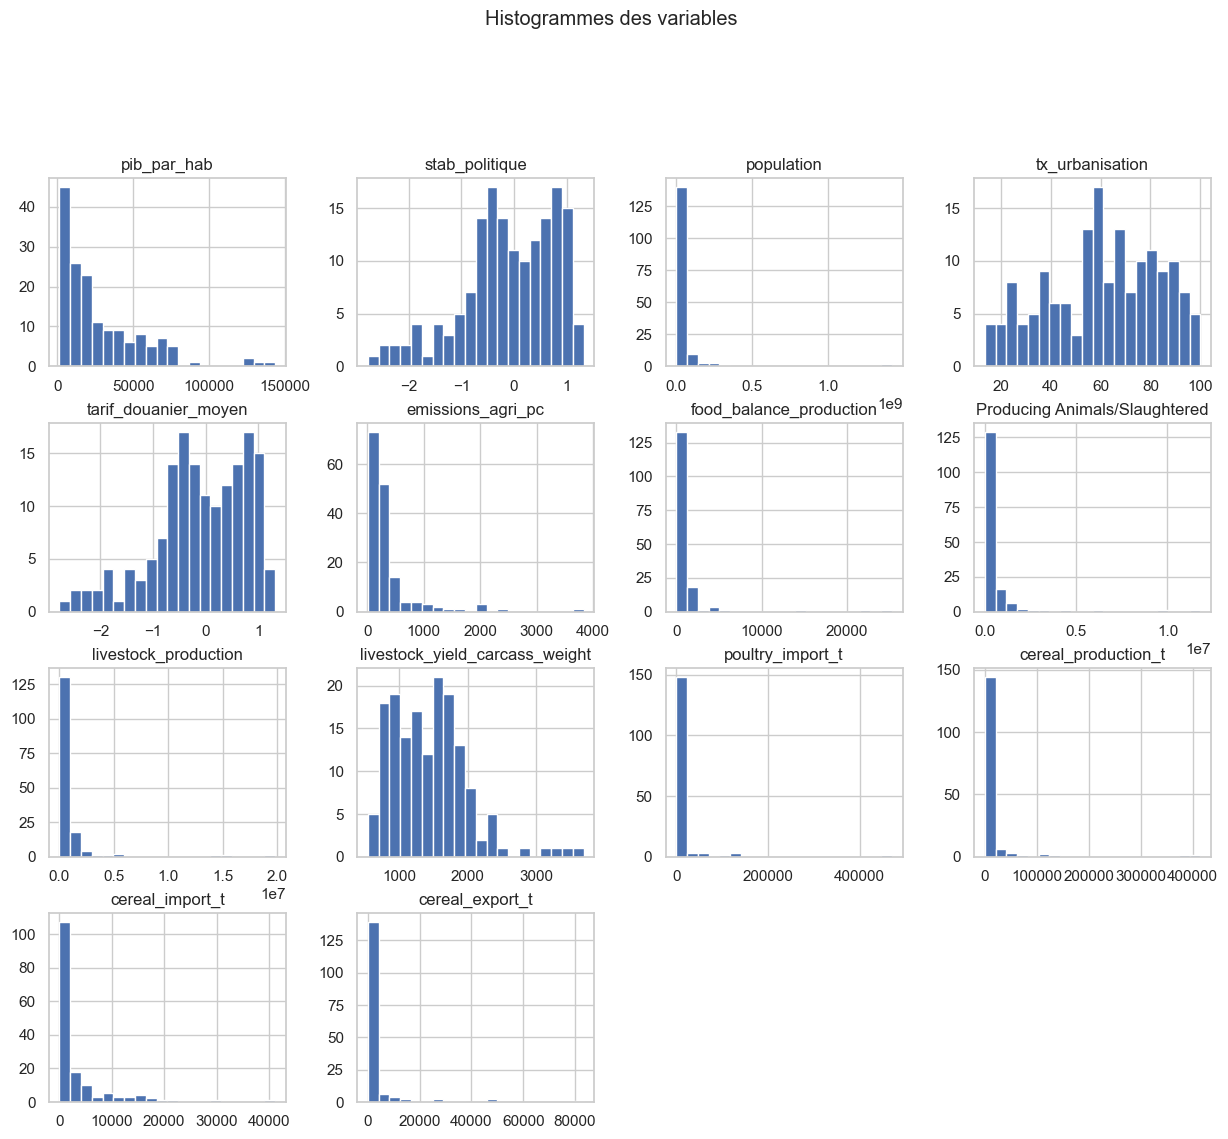

In [11]:
df_acp.hist(figsize=(15,12), bins=20)
plt.suptitle("Histogrammes des variables", y=1.02)
plt.show()


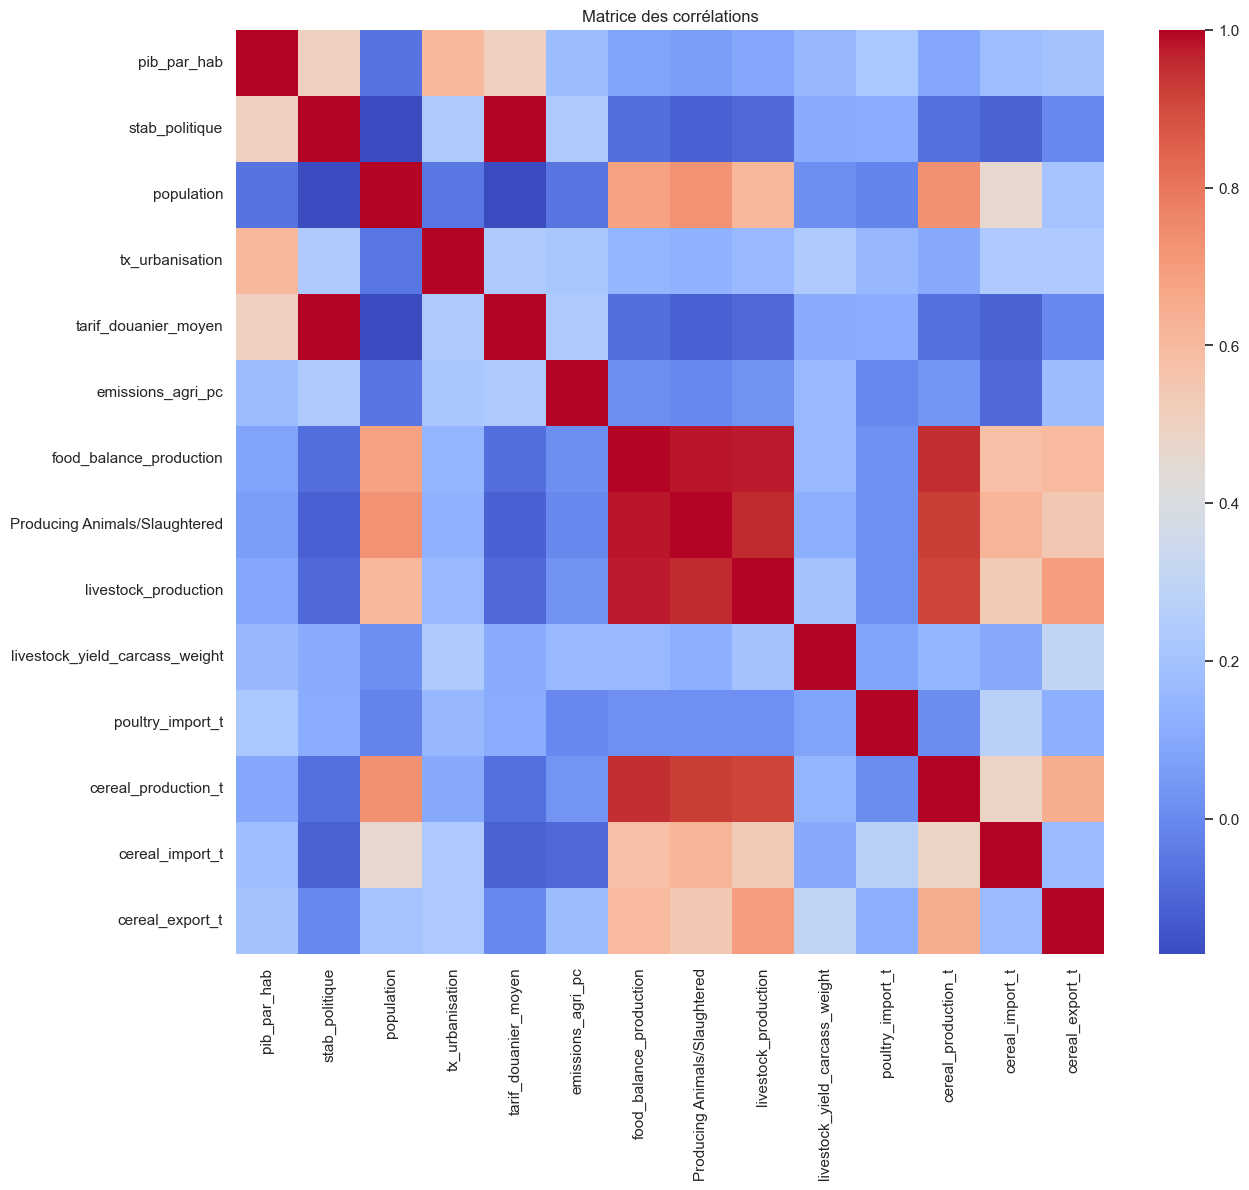

In [12]:
plt.figure(figsize=(14,12))
sns.heatmap(df_acp.corr(), cmap="coolwarm", annot=False)
plt.title("Matrice des corrélations")
plt.show()


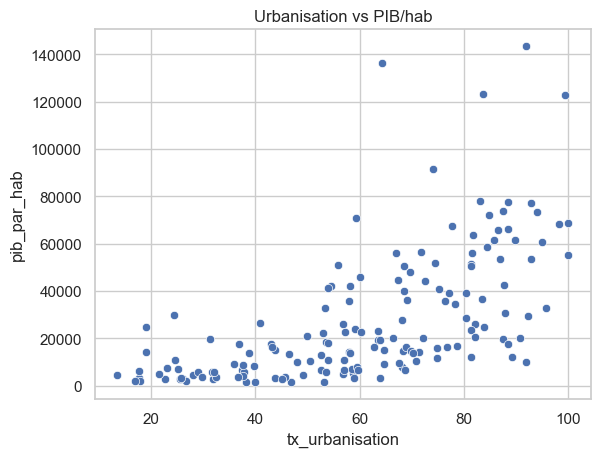

In [13]:
sns.scatterplot(data=df_acp, x="tx_urbanisation", y="pib_par_hab")
plt.title("Urbanisation vs PIB/hab")
plt.show()


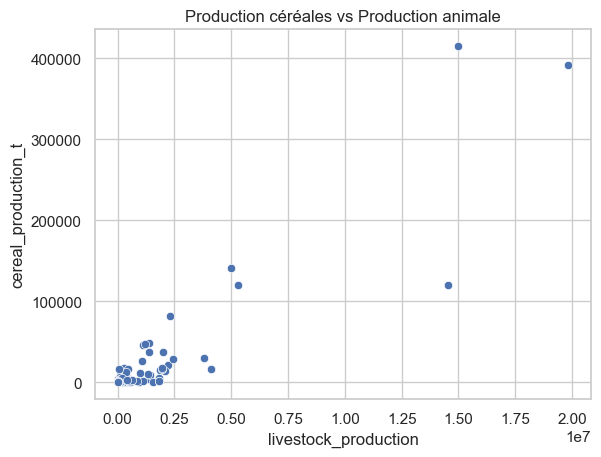

In [14]:
sns.scatterplot(data=df_acp, x="livestock_production", y="cereal_production_t")
plt.title("Production céréales vs Production animale")
plt.show()


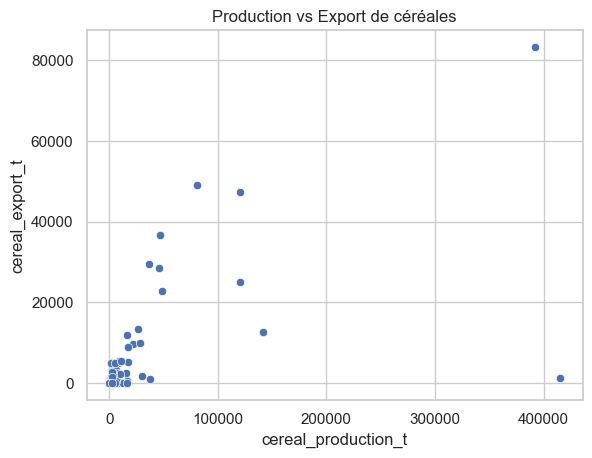

In [15]:
sns.scatterplot(data=df_acp, x="cereal_production_t", y="cereal_export_t")
plt.title("Production vs Export de céréales")
plt.show()


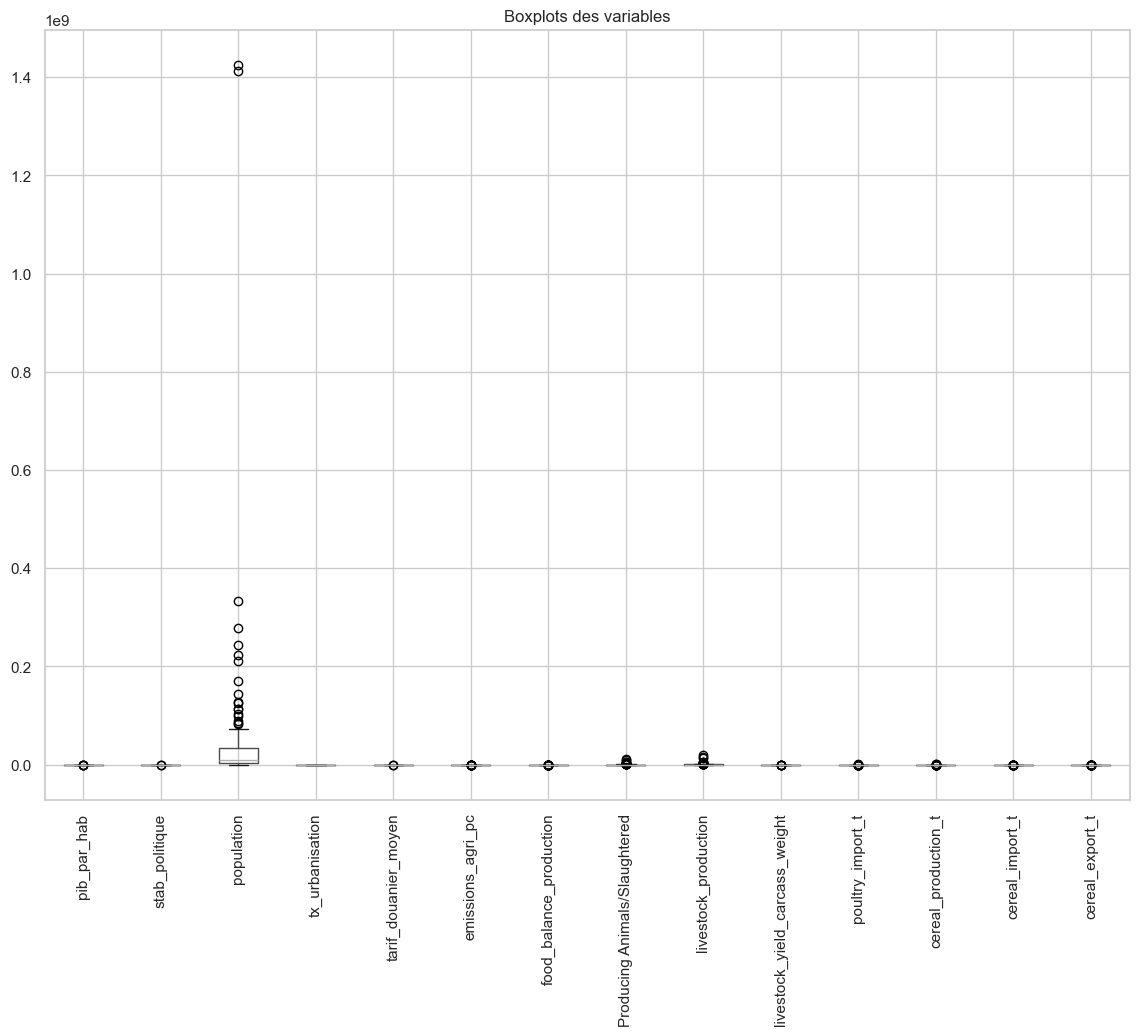

In [16]:
plt.figure(figsize=(14,10))
df_acp.boxplot(rot=90)
plt.title("Boxplots des variables")
plt.show()


In [17]:
# sns.pairplot(df_acp)
# plt.show()


In [18]:
#Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)


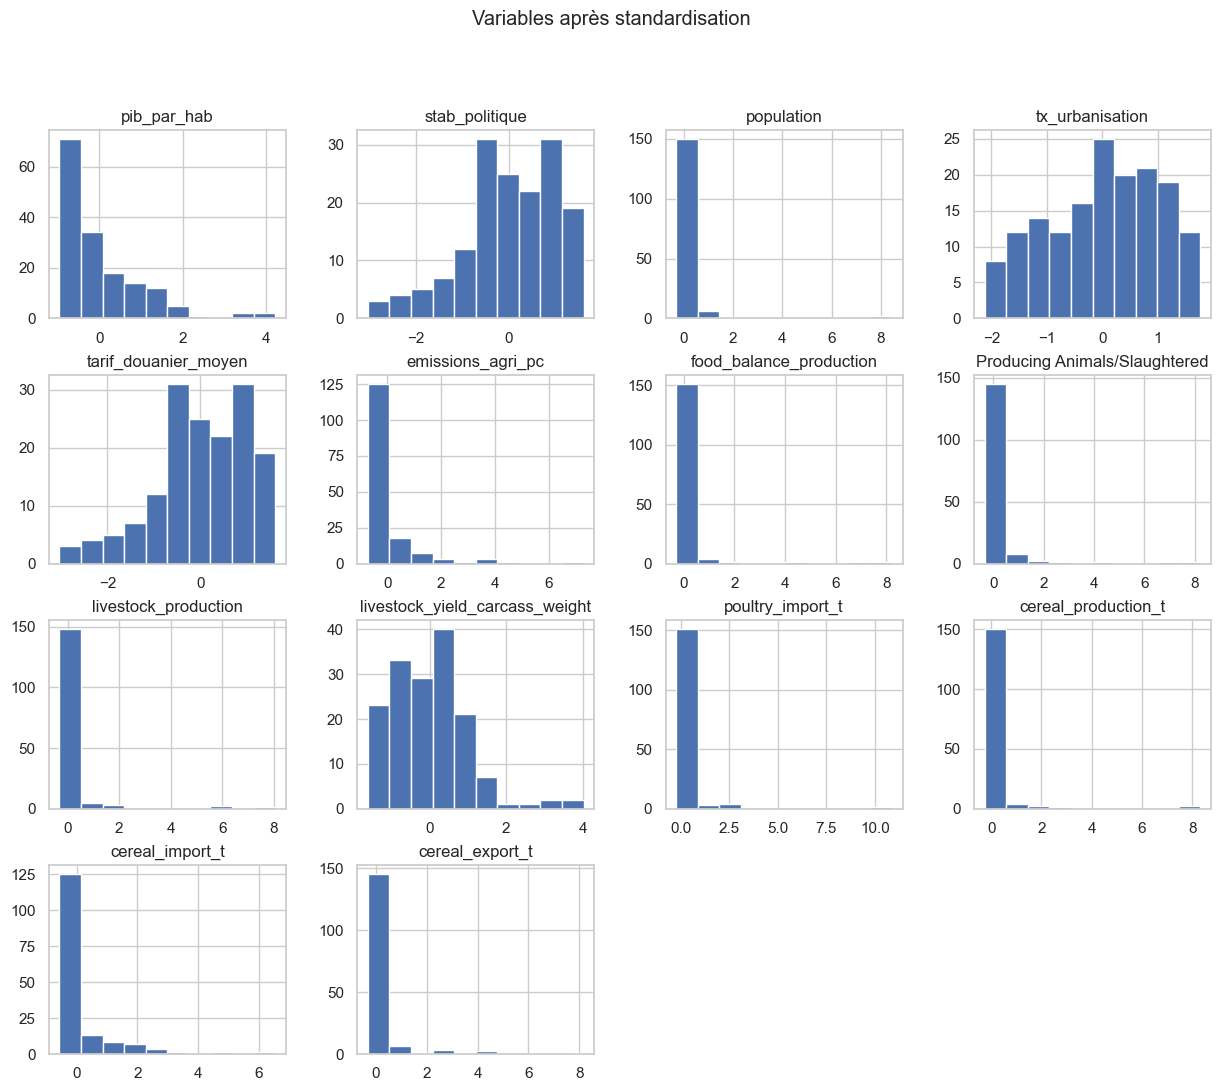

In [19]:
df_scaled = pd.DataFrame(X_scaled, columns=df_acp.columns)
df_scaled.hist(figsize=(15,12))
plt.suptitle("Variables après standardisation")
plt.show()


In [20]:
#ACP
pca = PCA(n_components=4)  # deux axes principaux
# pca = PCA()
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.37590482, 0.20522698, 0.08954725, 0.08628805])

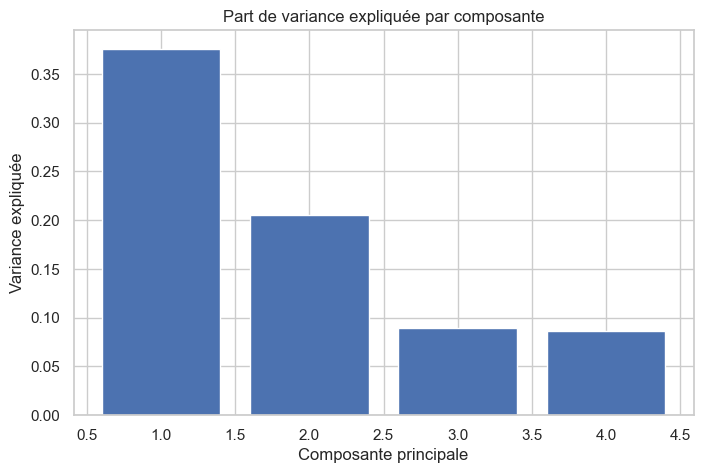

In [21]:
plt.figure(figsize=(8,5))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_)
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée")
plt.title("Part de variance expliquée par composante")
plt.show()


In [22]:
# Colonnes numériques réellement utilisées dans l'ACP
cols_acp = df_acp.columns.tolist()

print("Colonnes ACP retenues :", cols_acp)
print("Nombre :", len(cols_acp))


Colonnes ACP retenues : ['pib_par_hab', 'stab_politique', 'population', 'tx_urbanisation', 'tarif_douanier_moyen', 'emissions_agri_pc', 'food_balance_production', 'Producing Animals/Slaughtered', 'livestock_production', 'livestock_yield_carcass_weight', 'poultry_import_t', 'cereal_production_t', 'cereal_import_t', 'cereal_export_t']
Nombre : 14


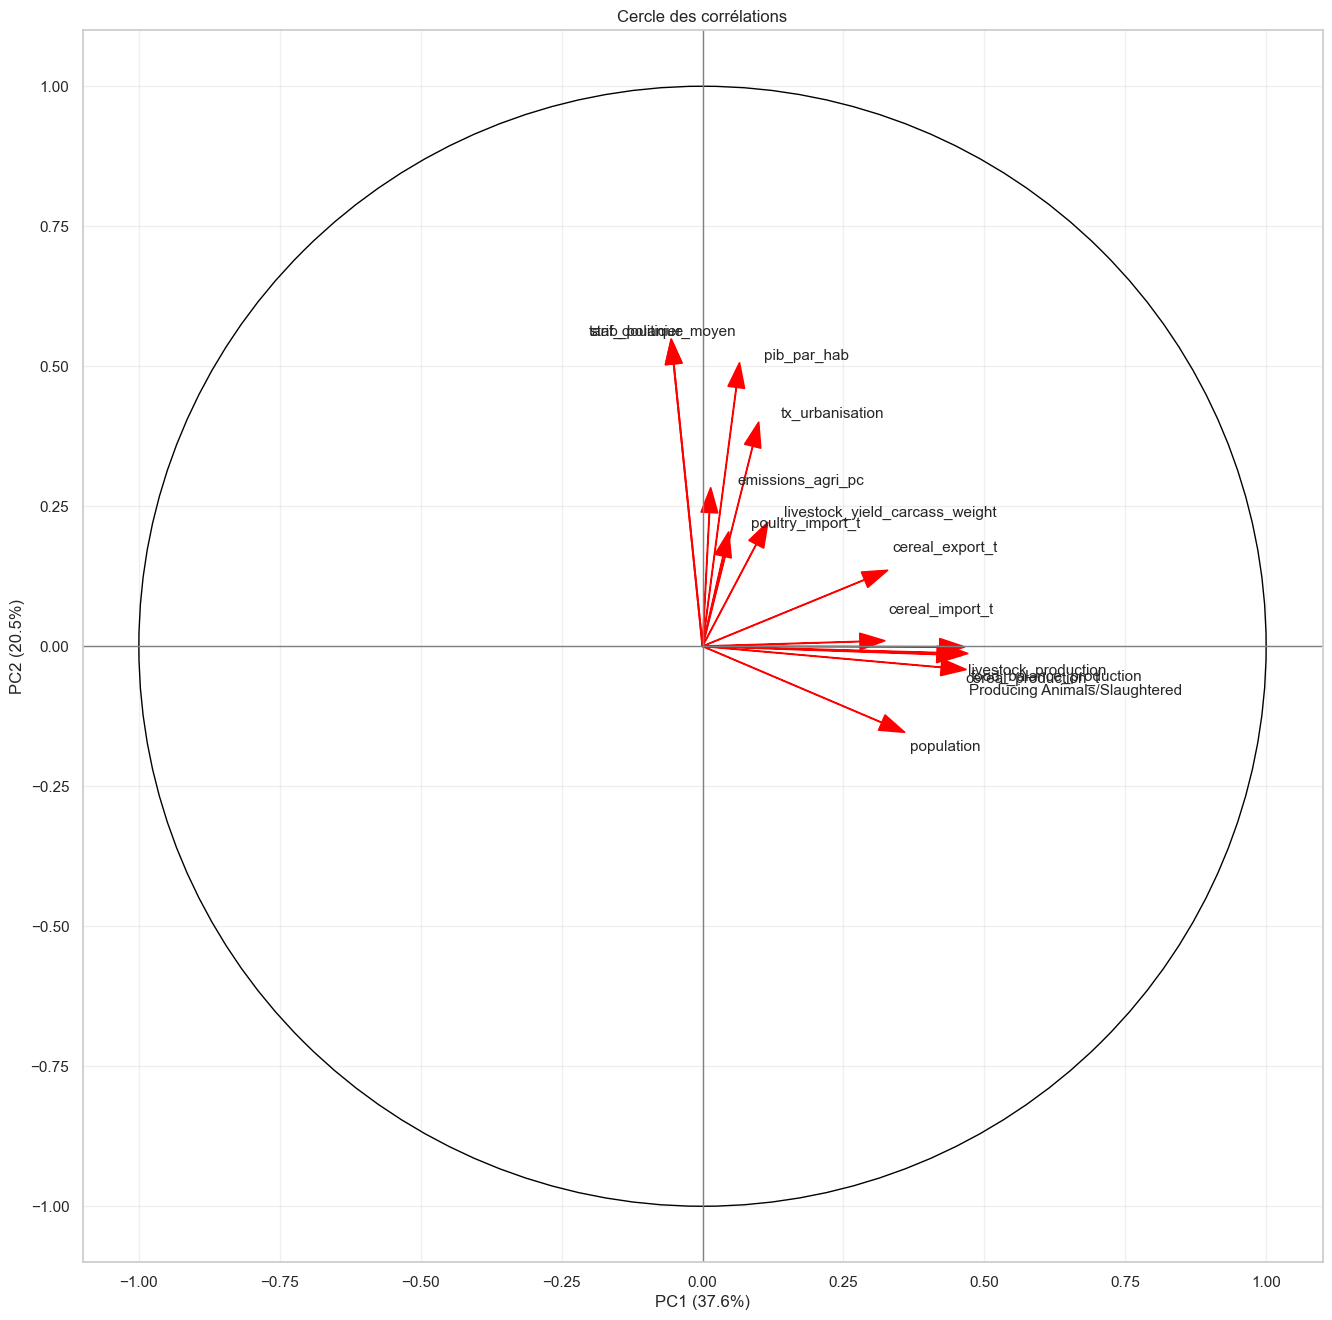

In [23]:
# plt.figure(figsize=(16,16))

# # Cercle unité
# circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1)
# plt.gca().add_artist(circle)

# # Vecteurs variables
# for i, col in enumerate(cols_acp):
#     plt.arrow(0, 0, 
#               pca.components_[0, i], 
#               pca.components_[1, i],
#               head_width=0.03, 
#               color='red')
#     plt.text(pca.components_[0, i]*1.1, 
#              pca.components_[1, i]*1.1, 
#              col, fontsize=9)
# plt.axhline(0, color='grey', linewidth=1)  # ligne horizontale (y = 0)
# plt.axvline(0, color='grey', linewidth=1)  # ligne verticale (x = 0)
# plt.xlim(-1.1, 1.1)
# plt.ylim(-1.1, 1.1)
# plt.xlabel("PC1 (%.1f%%)" % (pca.explained_variance_ratio_[0]*100))
# plt.ylabel("PC2 (%.1f%%)" % (pca.explained_variance_ratio_[1]*100))
# plt.title("Cercle des corrélations")
# plt.grid()
# plt.show()

plt.figure(figsize=(16,16))

# Cercle unité
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1)
plt.gca().add_artist(circle)

for i, col in enumerate(cols_acp):
    x = pca.components_[0, i]
    y = pca.components_[1, i]
    
    # Flèche
    plt.arrow(0, 0, x, y, head_width=0.03, color='red')
    
    # Décalage dynamique : 
    # à droite → texte à droite, 
    # à gauche → texte à gauche, etc.
    dx = 0.05 if x >= 0 else -0.15
    dy = 0.05 if y >= 0 else -0.05
    
    plt.text(x + dx, y + dy, col, fontsize=11)

plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Cercle des corrélations")
plt.grid(alpha=0.3)
plt.show()


In [24]:
# Loadings PC1 et PC2
pc1 = pca.components_[0]
pc2 = pca.components_[1]

threshold = 0.4  # seuil que tu peux ajuster

important_vars = []

for i, col in enumerate(cols_acp):
    if abs(pc1[i]) > threshold or abs(pc2[i]) > threshold:
        important_vars.append({
            "Variable": col,
            "PC1_loading": pc1[i],
            "PC2_loading": pc2[i]
        })

df_imp = pd.DataFrame(important_vars).sort_values(
    by=["PC1_loading", "PC2_loading"], 
    key=np.abs, 
    ascending=False
)

print(df_imp)

                        Variable  PC1_loading  PC2_loading
3        food_balance_production     0.426364    -0.011709
4  Producing Animals/Slaughtered     0.423518    -0.037644
5           livestock_production     0.420733    -0.001061
6            cereal_production_t     0.415779    -0.014465
0                    pib_par_hab     0.059963     0.462223
2           tarif_douanier_moyen    -0.051048     0.504142
1                 stab_politique    -0.051048     0.504142


In [25]:
donnees_acp["PC1"]=X_pca[:,0]
donnees_acp["PC2"]=X_pca[:,1]

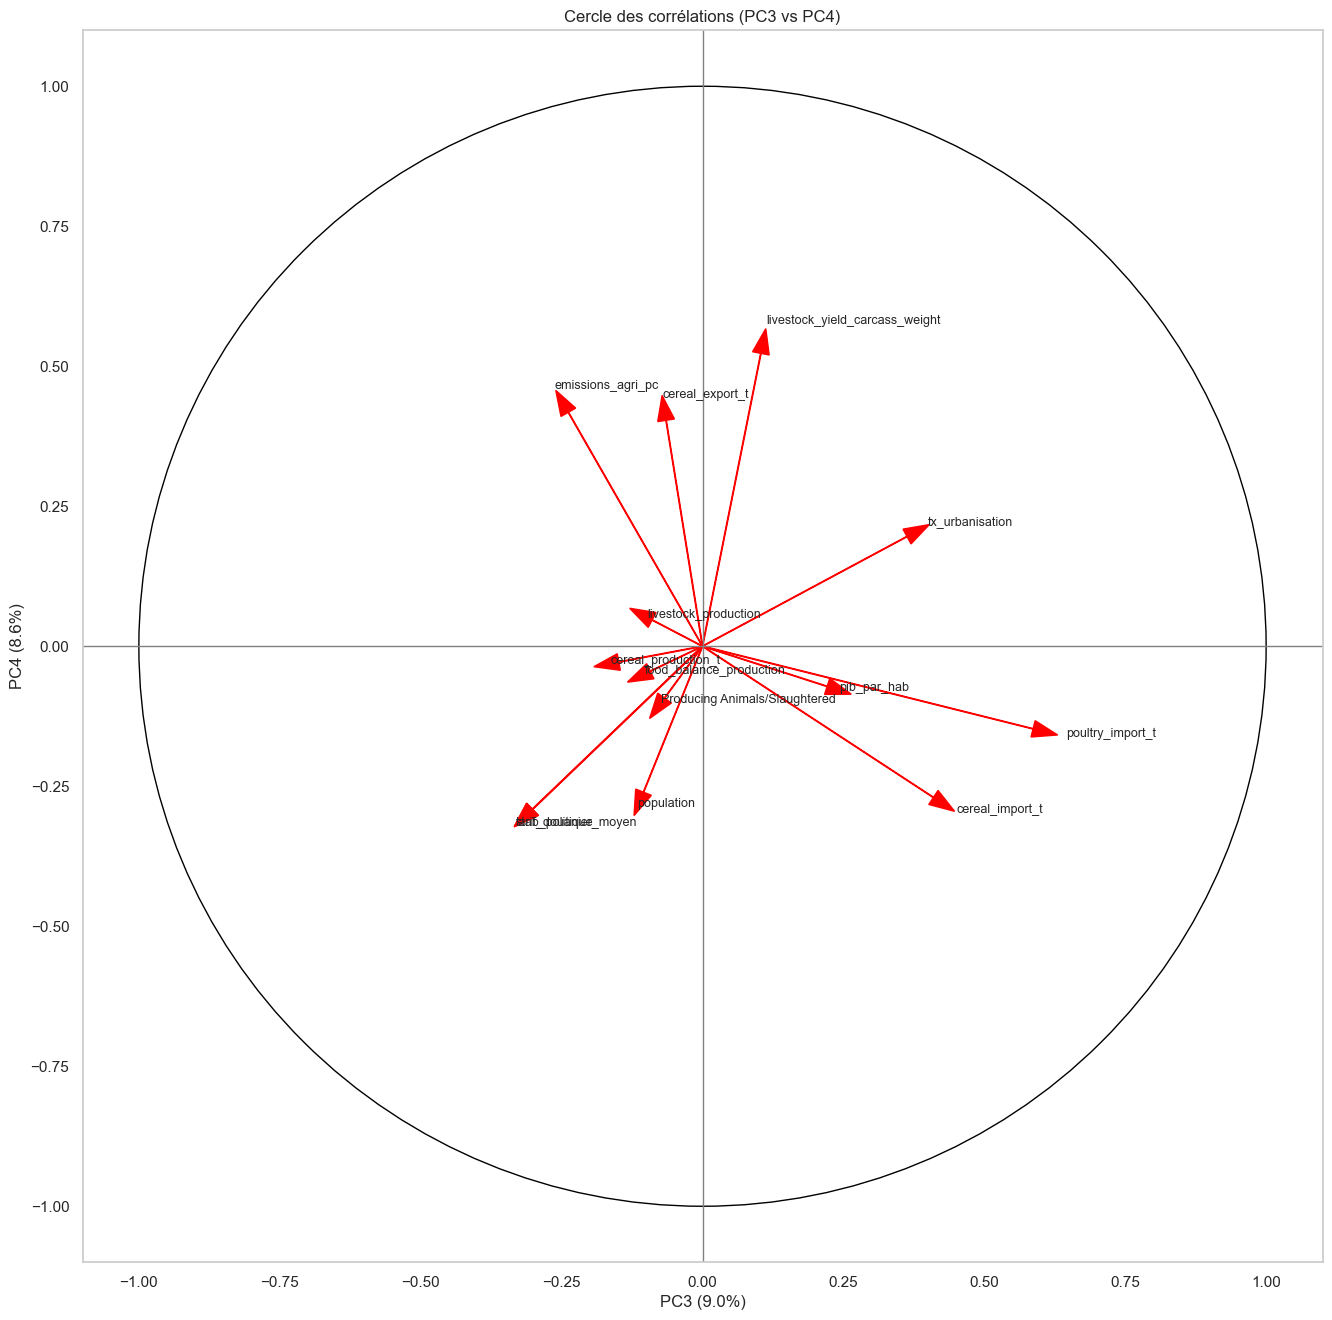

In [26]:
plt.figure(figsize=(16,16))

# Cercle unité
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1)
plt.gca().add_artist(circle)

# Vecteurs variables (PC3 = composante 2, PC4 = composante 3)
for i, col in enumerate(cols_acp):
    plt.arrow(0, 0, 
              pca.components_[2, i],   # PC3
              pca.components_[3, i],   # PC4
              head_width=0.03, 
              color='red')
    plt.text(pca.components_[2, i]*1.1, 
             pca.components_[3, i]*1.1, 
             col, fontsize=9)

# Axes
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("PC3 (%.1f%%)" % (pca.explained_variance_ratio_[2]*100))
plt.ylabel("PC4 (%.1f%%)" % (pca.explained_variance_ratio_[3]*100))

plt.title("Cercle des corrélations (PC3 vs PC4)")
plt.grid()
plt.show()


In [27]:
# Loadings PC3 et PC4
pc3 = pca.components_[2]
pc4 = pca.components_[3]

threshold = 0.35  # seuil recommandé car PC3 & PC4 ont des valeurs plus petites

important_vars_pc3_pc4 = []

for i, col in enumerate(cols_acp):
    if abs(pc3[i]) > threshold or abs(pc4[i]) > threshold:
        important_vars_pc3_pc4.append({
            "Variable": col,
            "PC3_loading": pc3[i],
            "PC4_loading": pc4[i]
        })

df_imp34 = pd.DataFrame(important_vars_pc3_pc4).sort_values(
    by=["PC3_loading", "PC4_loading"],
    key=np.abs,
    ascending=False
)

print("\n===== VARIABLES IMPORTANTES PC3–PC4 =====")
print(df_imp34)


===== VARIABLES IMPORTANTES PC3–PC4 =====
                         Variable  PC3_loading  PC4_loading
3                poultry_import_t     0.586495    -0.147467
4                 cereal_import_t     0.409700    -0.269993
0                 tx_urbanisation     0.362844     0.195906
1               emissions_agri_pc    -0.238022     0.417805
2  livestock_yield_carcass_weight     0.103566     0.523004
5                 cereal_export_t    -0.064581     0.403507


In [28]:
donnees_acp["PC3"]=X_pca[:,2]
donnees_acp["PC4"]=X_pca[:,3]

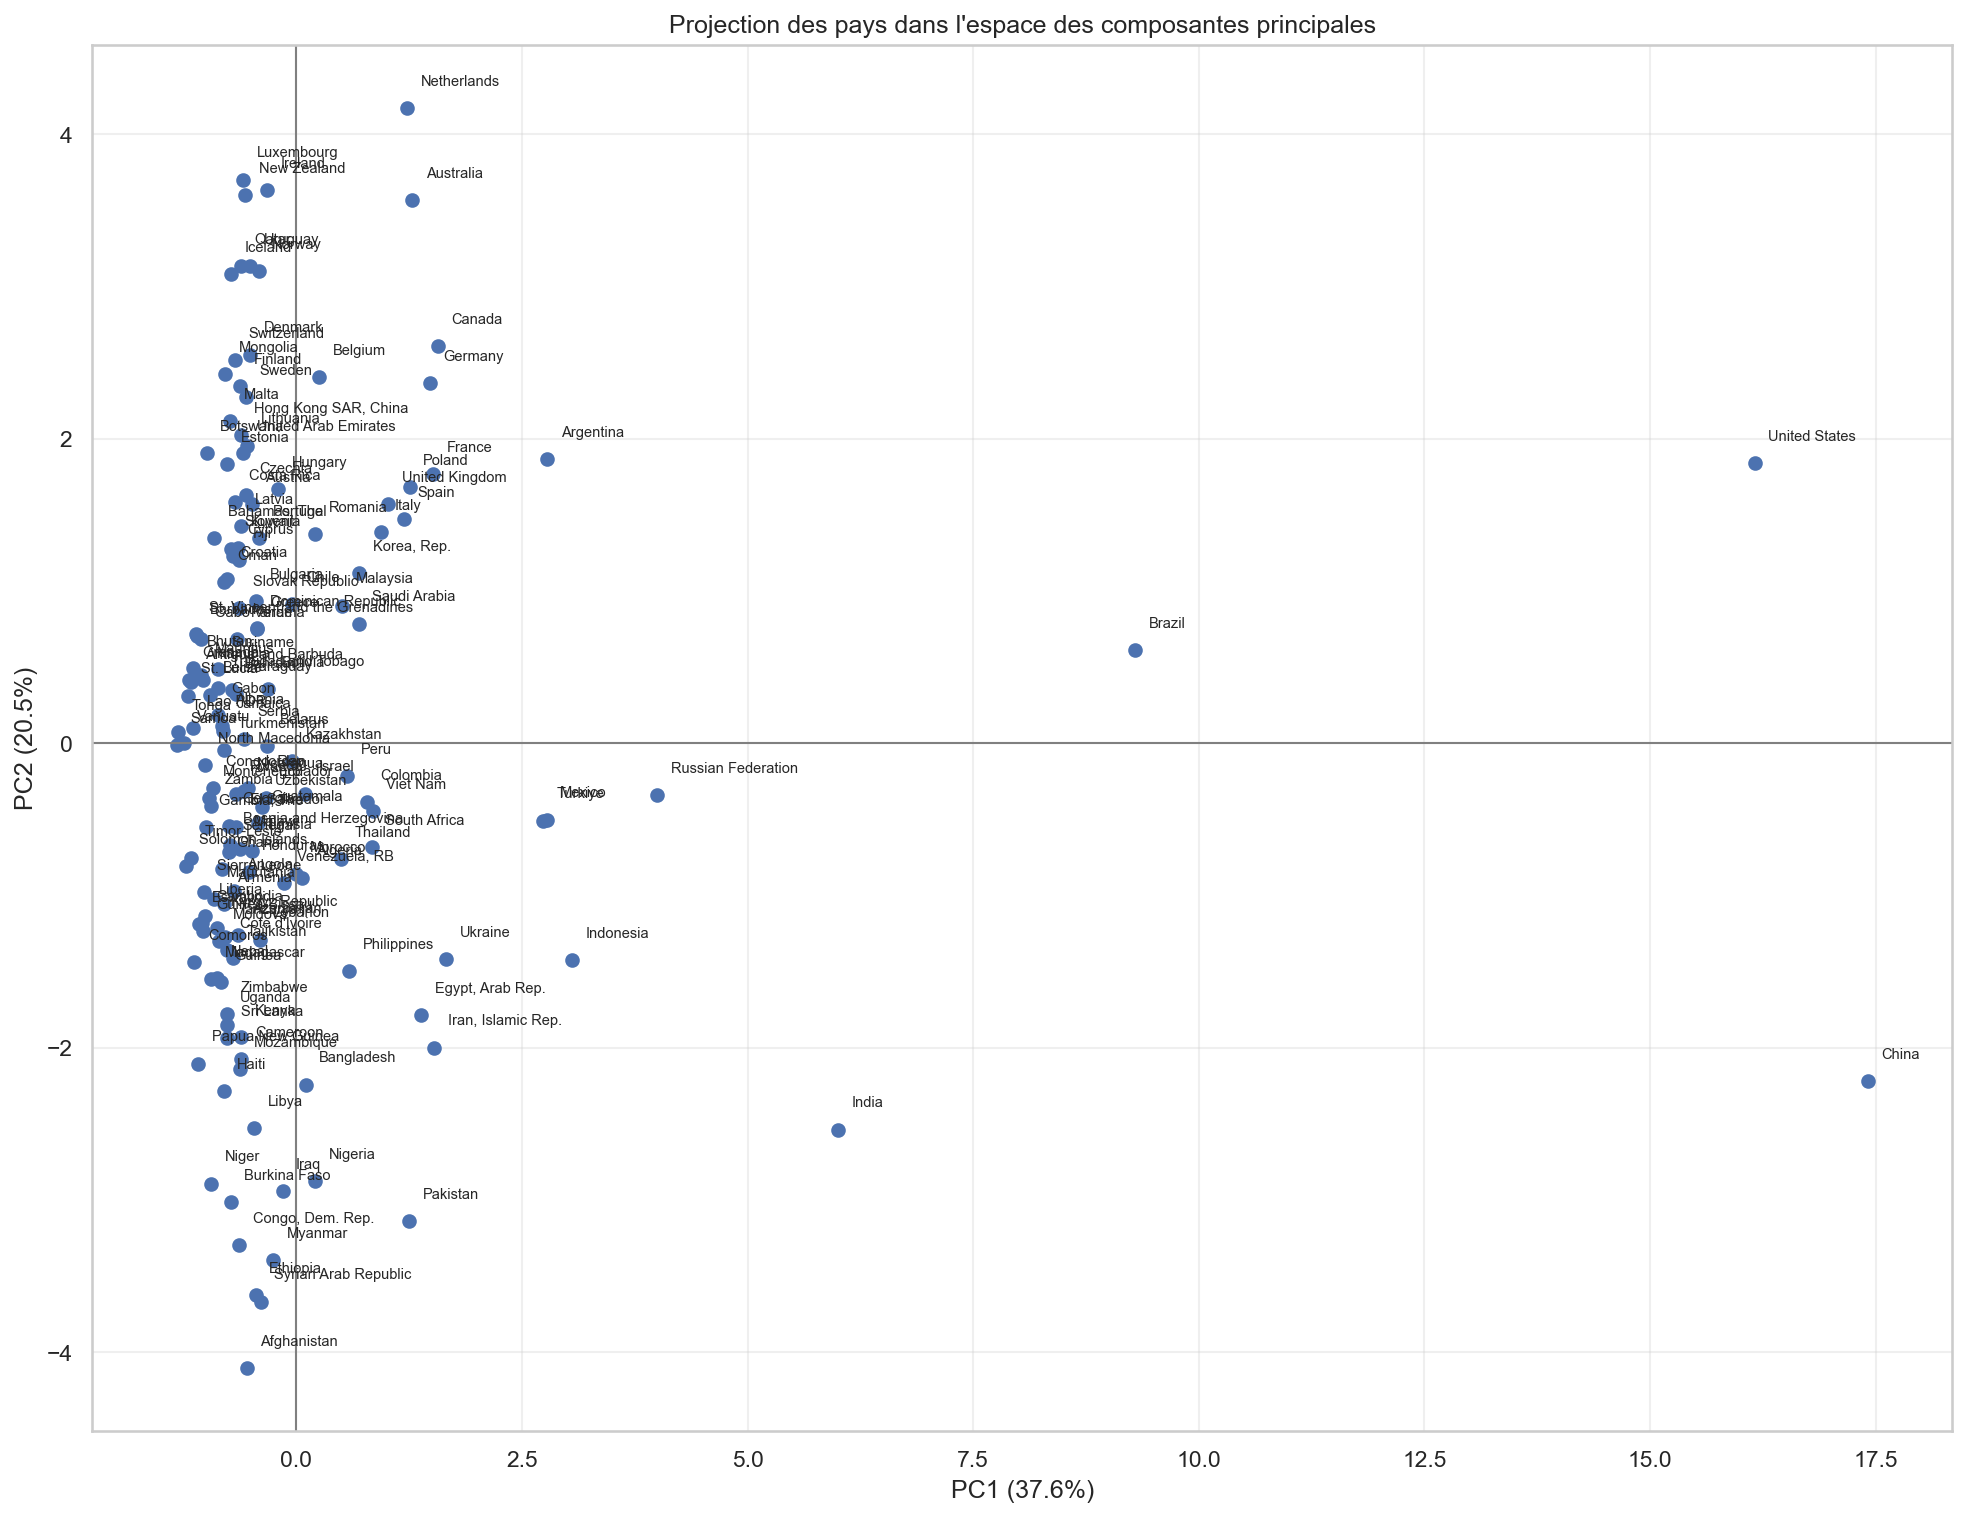

In [29]:
plt.figure(figsize=(16,12),dpi=150)
plt.scatter(donnees_acp["PC1"], donnees_acp["PC2"])

# Labels décalés
for i in range(donnees_acp.shape[0]):
    x = donnees_acp["PC1"].iloc[i]
    y = donnees_acp["PC2"].iloc[i]
    country = donnees_acp["Country"].iloc[i]
    plt.text(x + 0.15, y + 0.15, country, fontsize=7)
    
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlabel("PC1 (%.1f%%)" % (pca.explained_variance_ratio_[0]*100))
plt.ylabel("PC2 (%.1f%%)" % (pca.explained_variance_ratio_[1]*100))
plt.title("Projection des pays dans l'espace des composantes principales")
plt.grid(alpha=0.3)
plt.show()


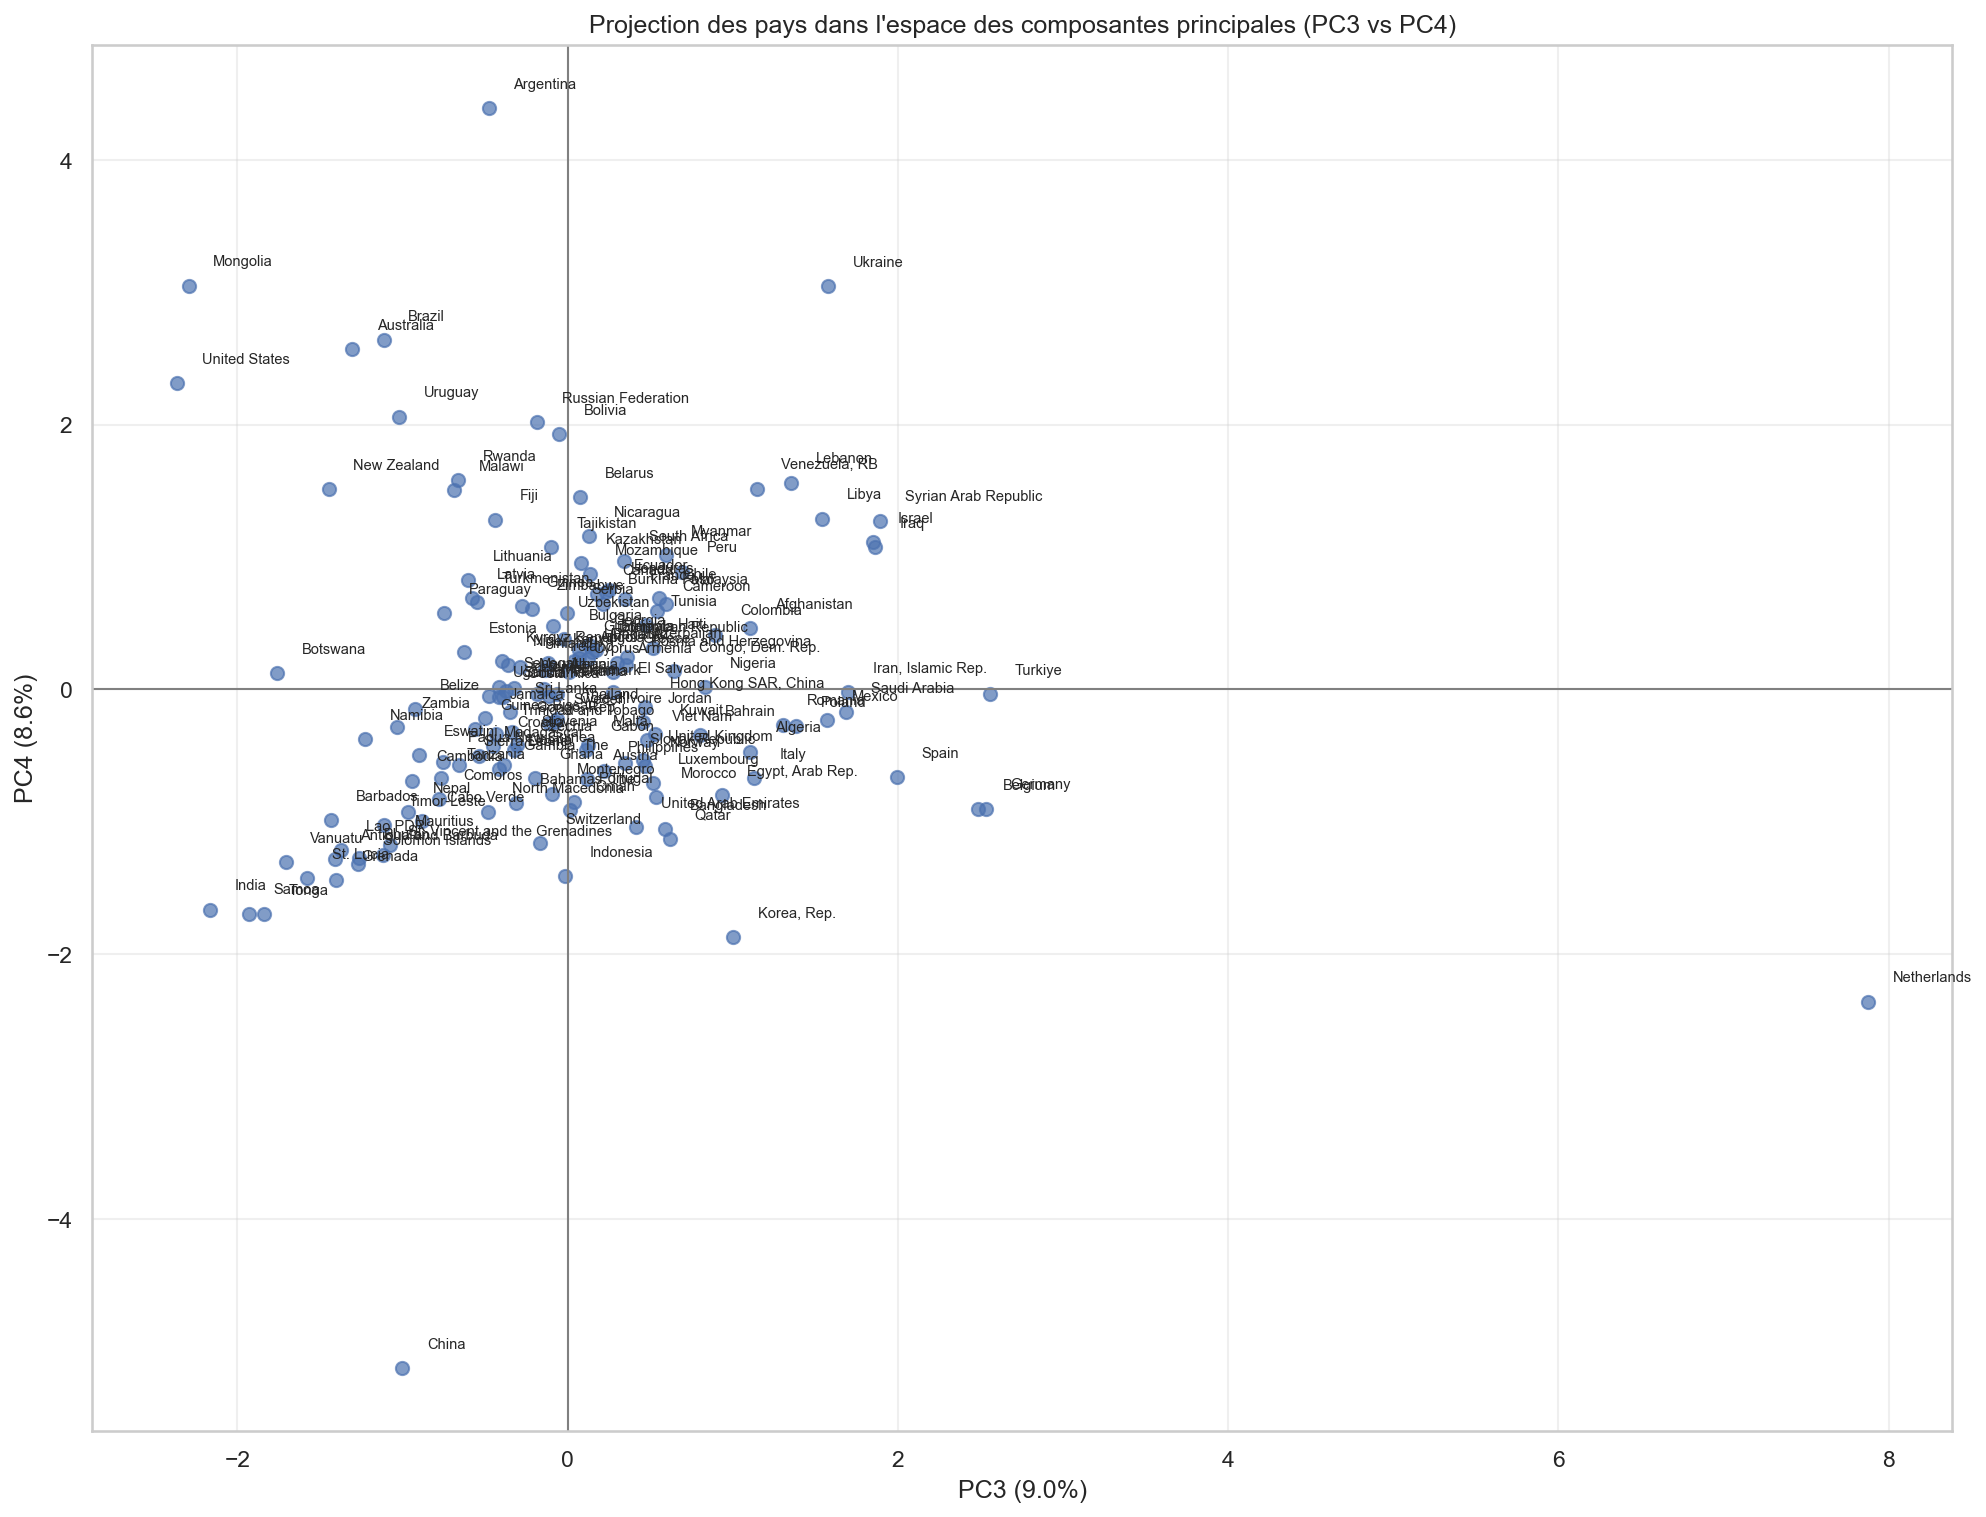

In [30]:
plt.figure(figsize=(16,12), dpi=150)

plt.scatter(donnees_acp["PC3"], donnees_acp["PC4"], s=40, alpha=0.7)

# Labels décalés
for i in range(donnees_acp.shape[0]):
    x = donnees_acp["PC3"].iloc[i]
    y = donnees_acp["PC4"].iloc[i]
    country = donnees_acp["Country"].iloc[i]
    plt.text(x + 0.15, y + 0.15, country, fontsize=7)

plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlabel("PC3 (%.1f%%)" % (pca.explained_variance_ratio_[2]*100))
plt.ylabel("PC4 (%.1f%%)" % (pca.explained_variance_ratio_[3]*100))
plt.title("Projection des pays dans l'espace des composantes principales (PC3 vs PC4)")
plt.grid(alpha=0.3)
plt.show()


CAH

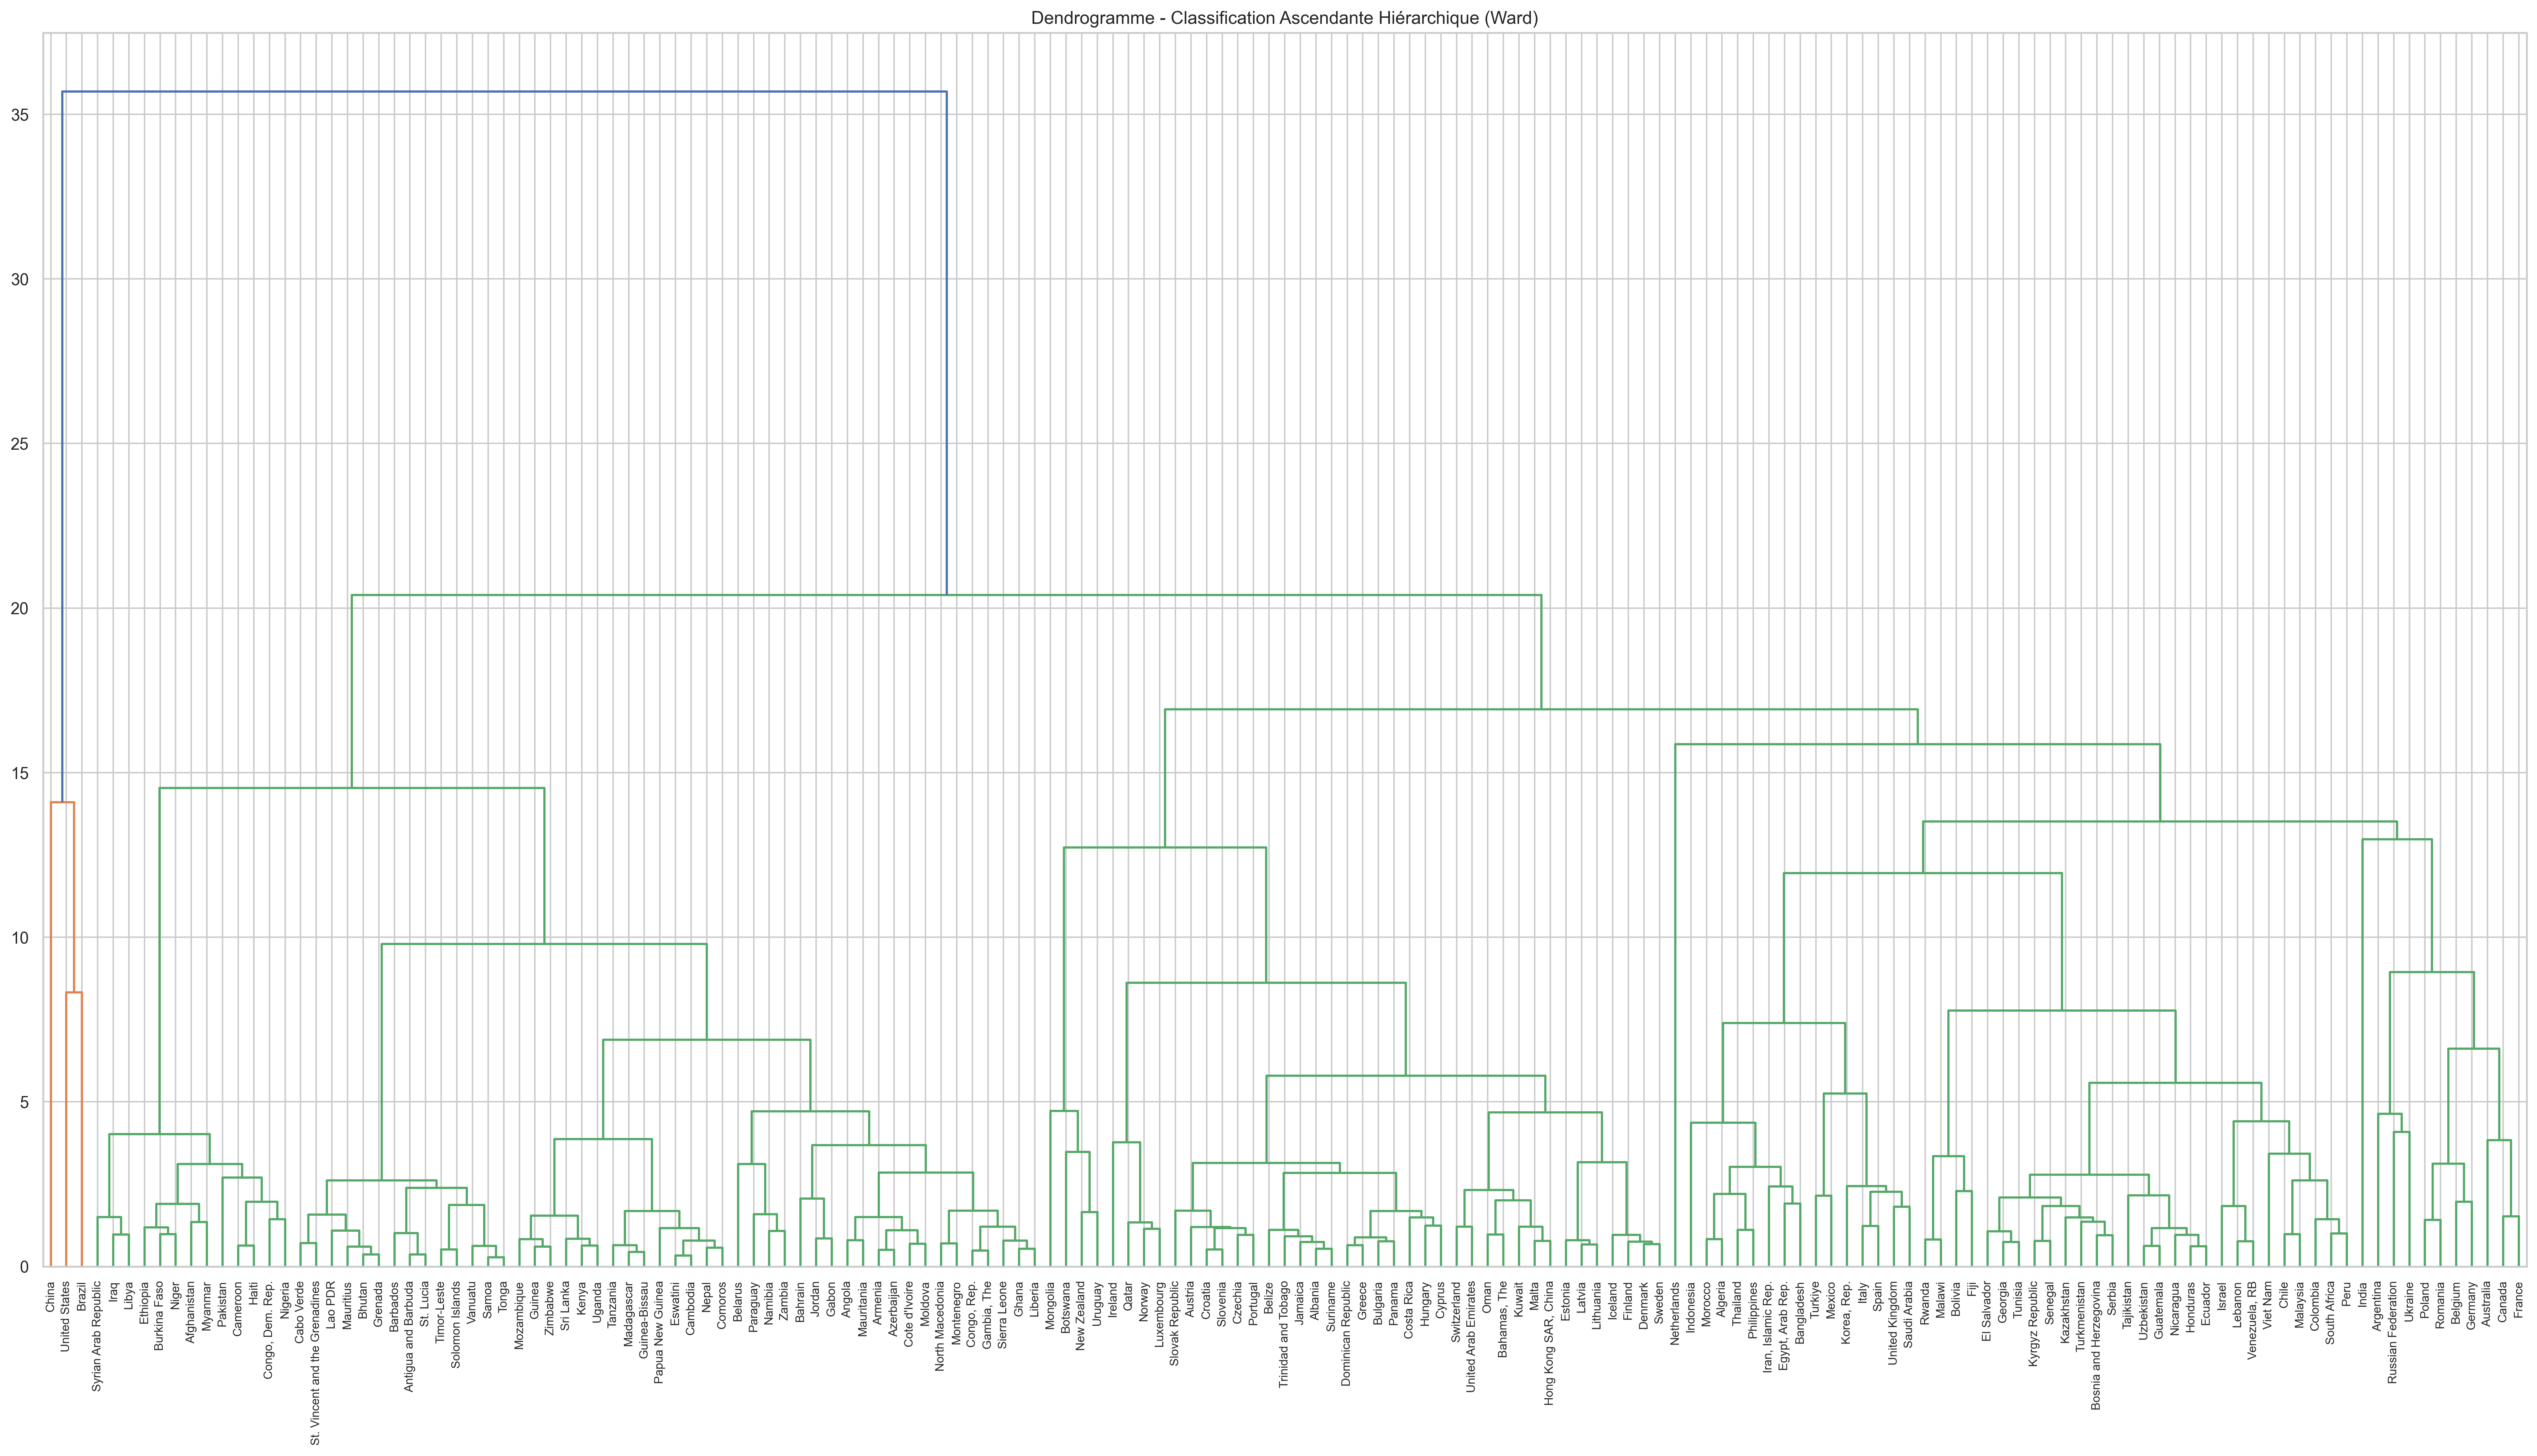

In [31]:
# CAH avec méthode Ward 
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(30, 15),dpi=300)
dendrogram(
    Z,
    labels=donnees_acp["Country"].values,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Dendrogramme - Classification Ascendante Hiérarchique (Ward)")
plt.show()

In [32]:
# Création du dendrogramme interactif
fig = ff.create_dendrogram(
    X_scaled,
    labels=donnees_acp["Country"].values,
    orientation='bottom',
    linkagefun=lambda x: linkage(x, method='ward')
)

# Taille du graphique
fig.update_layout(
    width=1400,
    height=800,
    title="Dendrogramme interactif - CAH (Ward)",
    xaxis=dict(tickfont=dict(size=10)),
)

fig.show()

k-means

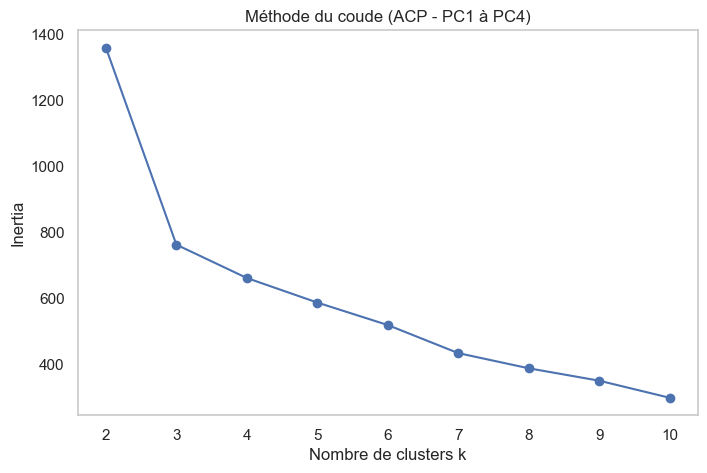

In [33]:
X_kmeans = donnees_acp[["PC1", "PC2", "PC3", "PC4"]].values

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_kmeans)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertia")
plt.title("Méthode du coude (ACP - PC1 à PC4)")
plt.grid()
plt.show()


In [34]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
donnees_acp["cluster"] = kmeans.fit_predict(X_kmeans)


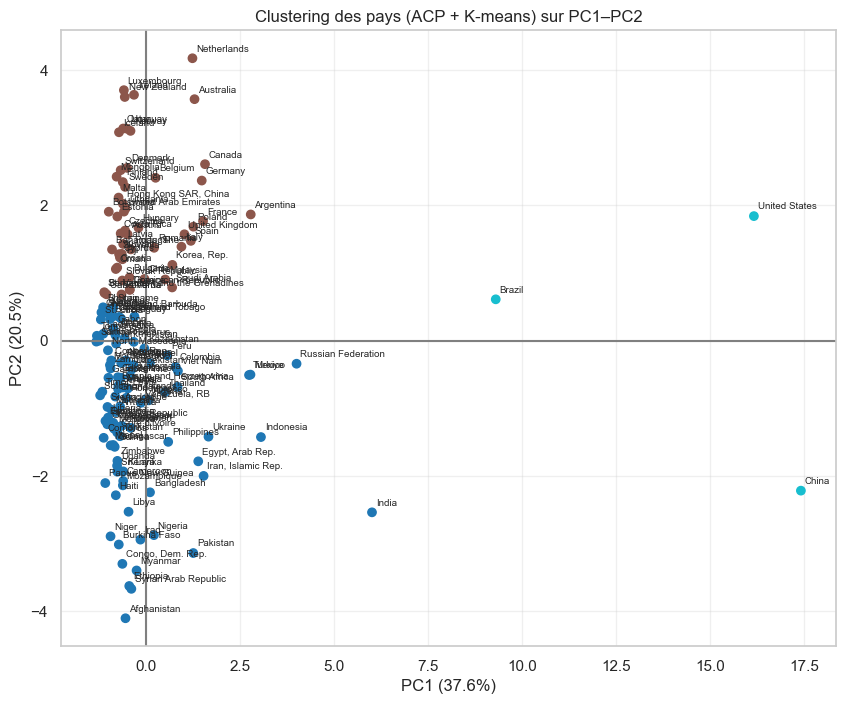

In [35]:
plt.figure(figsize=(10,8))
plt.scatter(donnees_acp["PC1"], donnees_acp["PC2"], 
            c=donnees_acp["cluster"], cmap="tab10")

for i in range(donnees_acp.shape[0]):
    plt.text(donnees_acp["PC1"].iloc[i]+0.1,
             donnees_acp["PC2"].iloc[i]+0.1,
             donnees_acp["Country"].iloc[i], fontsize=7)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Clustering des pays (ACP + K-means) sur PC1–PC2")
plt.grid(alpha=0.3)
plt.show()


In [36]:
fig = px.scatter(
    donnees_acp,
    x="PC1",
    y="PC2",
    color="cluster",
    hover_name="Country",
    hover_data={"PC1":":.2f", "PC2":":.2f"},
    title="Clustering des pays (ACP + K-means) – Graphique interactif"
)

# Ajout des lignes verticales/horizontales
fig.add_shape(type="line", x0=0, y0=donnees_acp["PC2"].min(),
              x1=0, y1=donnees_acp["PC2"].max(),
              line=dict(color="grey", width=1))

fig.add_shape(type="line", x0=donnees_acp["PC1"].min(), y0=0,
              x1=donnees_acp["PC1"].max(), y1=0,
              line=dict(color="grey", width=1))

fig.update_layout(
    width=900,
    height=700,
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
)

fig.show()

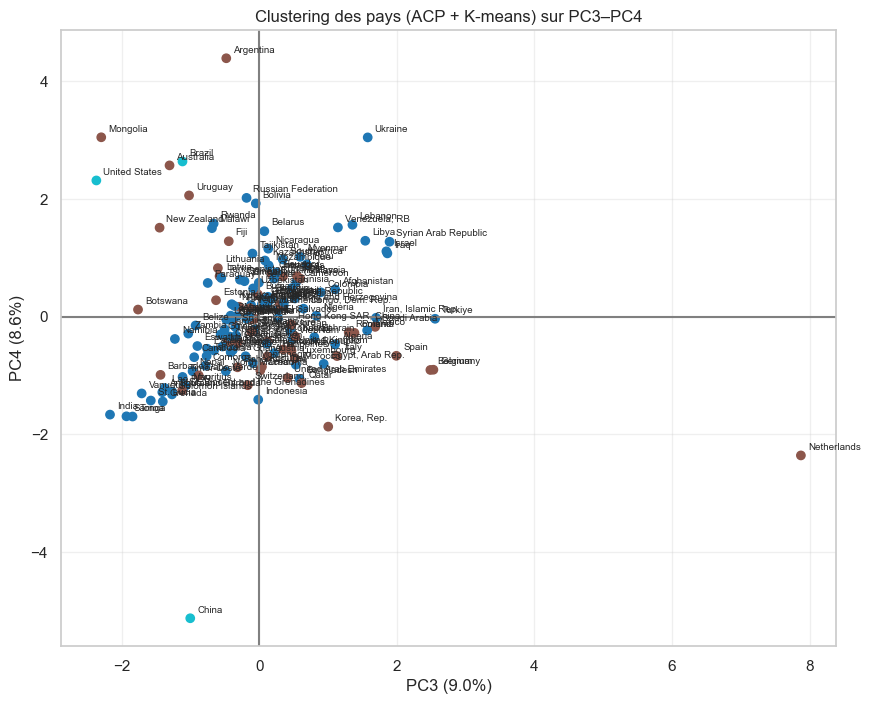

In [37]:
plt.figure(figsize=(10,8))
plt.scatter(donnees_acp["PC3"], donnees_acp["PC4"], 
            c=donnees_acp["cluster"], cmap="tab10")

for i in range(donnees_acp.shape[0]):
    plt.text(donnees_acp["PC3"].iloc[i]+0.1,
             donnees_acp["PC4"].iloc[i]+0.1,
             donnees_acp["Country"].iloc[i], fontsize=7)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')

plt.xlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
plt.ylabel(f"PC4 ({pca.explained_variance_ratio_[3]*100:.1f}%)")
plt.title("Clustering des pays (ACP + K-means) sur PC3–PC4")
plt.grid(alpha=0.3)
plt.show()

In [38]:
fig = px.scatter(
    donnees_acp,
    x="PC3",
    y="PC4",
    color="cluster",
    hover_name="Country",
    hover_data={"PC3":":.2f", "PC4":":.2f"},
    title="Clustering des pays (ACP + K-means) – Plan PC3–PC4"
)

# Lignes verticales et horizontales
fig.add_shape(type="line", 
              x0=0, y0=donnees_acp["PC4"].min(),
              x1=0, y1=donnees_acp["PC4"].max(),
              line=dict(color="grey", width=1))

fig.add_shape(type="line",
              x0=donnees_acp["PC3"].min(), y0=0,
              x1=donnees_acp["PC3"].max(), y1=0,
              line=dict(color="grey", width=1))

fig.update_layout(
    width=900,
    height=700,
    xaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)",
    yaxis_title=f"PC4 ({pca.explained_variance_ratio_[3]*100:.1f}%)",
)

fig.show()


In [39]:
donnees_acp[["Country", "cluster"]].sort_values("cluster").reset_index(drop=True)


,Country,cluster
0,Bosnia and Herzegovina,0
1,Cameroon,0
2,Belarus,0
3,Sri Lanka,0
4,Kyrgyz Republic,0
...,...,...
154,St. Vincent and the Grenadines,1
155,"Hong Kong SAR, China",1
156,Brazil,2
157,United States,2


In [40]:
donnees_acp["cluster"].value_counts()


cluster
0    101
1     55
2      3
Name: count, dtype: int64

# Réduire la taille d'effet

In [41]:
df_acp.head()

,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,emissions_agri_pc,food_balance_production,Producing Animals/Slaughtered,livestock_production,livestock_yield_carcass_weight,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t
0,21117.283077,-0.483194,3204802.0,49.841,-0.483194,234.02382,67.0,43537.0,67007.00,1539.0,29708.0,1268.0,773.0,100.0
1,91326.131705,1.159745,8777088.0,74.092,1.159745,143.30917,112.0,87825.0,109515.00,1247.0,309.0,612.0,1606.0,184.0
2,68157.834786,0.581982,11680210.0,98.153,0.581982,175.23042,450.0,297794.0,442020.00,1484.0,109384.0,2352.0,9771.0,3460.0
3,5188.977509,-1.379629,27632771.0,58.733,-1.379629,187.82048,127.0,104117.0,127126.07,1221.0,1039.0,2201.0,1020.0,22.0
4,63578.320195,0.780682,38935934.0,81.752,0.780682,872.97530,1532.0,789394.0,1370800.00,1737.0,31890.0,48895.0,8213.0,22936.0


In [42]:
variables_a_normaliser = [
    "cereal_production_t",
    "livestock_production",
    "Producing Animals/Slaughtered",
    "food_balance_production",
    "cereal_import_t",
    "cereal_export_t",
    "poultry_import_t"
]

for var in variables_a_normaliser:
    df_acp[var + "_per_capita"] = df_acp[var] / df_acp["population"]


In [43]:
corr_pop = df_acp.corr()["population"].sort_values(ascending=False)
print(corr_pop)

population                                  1.000000
cereal_production_t                         0.733030
Producing Animals/Slaughtered               0.725734
food_balance_production                     0.682966
livestock_production                        0.613514
cereal_import_t                             0.456637
cereal_export_t                             0.200435
cereal_production_t_per_capita              0.037027
livestock_yield_carcass_weight              0.014190
food_balance_production_per_capita          0.005347
poultry_import_t                           -0.016241
livestock_production_per_capita            -0.018047
Producing Animals/Slaughtered_per_capita   -0.032648
tx_urbanisation                            -0.054680
cereal_export_t_per_capita                 -0.058856
emissions_agri_pc                          -0.060803
pib_par_hab                                -0.065067
poultry_import_t_per_capita                -0.068712
cereal_import_t_per_capita                 -0.

In [44]:
vars_to_remove = [
    "cereal_production_t",
    "livestock_production",
    "Producing Animals/Slaughtered",
    "food_balance_production",
    "cereal_import_t",
    "cereal_export_t",
    "poultry_import_t"
]

df_acp = df_acp.drop(columns=vars_to_remove)
df_acp.head()

,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,emissions_agri_pc,livestock_yield_carcass_weight,cereal_production_t_per_capita,livestock_production_per_capita,Producing Animals/Slaughtered_per_capita,food_balance_production_per_capita,cereal_import_t_per_capita,cereal_export_t_per_capita,poultry_import_t_per_capita
0,21117.283077,-0.483194,3204802.0,49.841,-0.483194,234.02382,1539.0,0.000396,0.020908,0.013585,0.000021,0.000241,3.120318e-05,0.009270
1,91326.131705,1.159745,8777088.0,74.092,1.159745,143.30917,1247.0,0.000070,0.012477,0.010006,0.000013,0.000183,2.096367e-05,0.000035
2,68157.834786,0.581982,11680210.0,98.153,0.581982,175.23042,1484.0,0.000201,0.037843,0.025496,0.000039,0.000837,2.962276e-04,0.009365
3,5188.977509,-1.379629,27632771.0,58.733,-1.379629,187.82048,1221.0,0.000080,0.004601,0.003768,0.000005,0.000037,7.961561e-07,0.000038
4,63578.320195,0.780682,38935934.0,81.752,0.780682,872.97530,1737.0,0.001256,0.035207,0.020274,0.000039,0.000211,5.890702e-04,0.000819


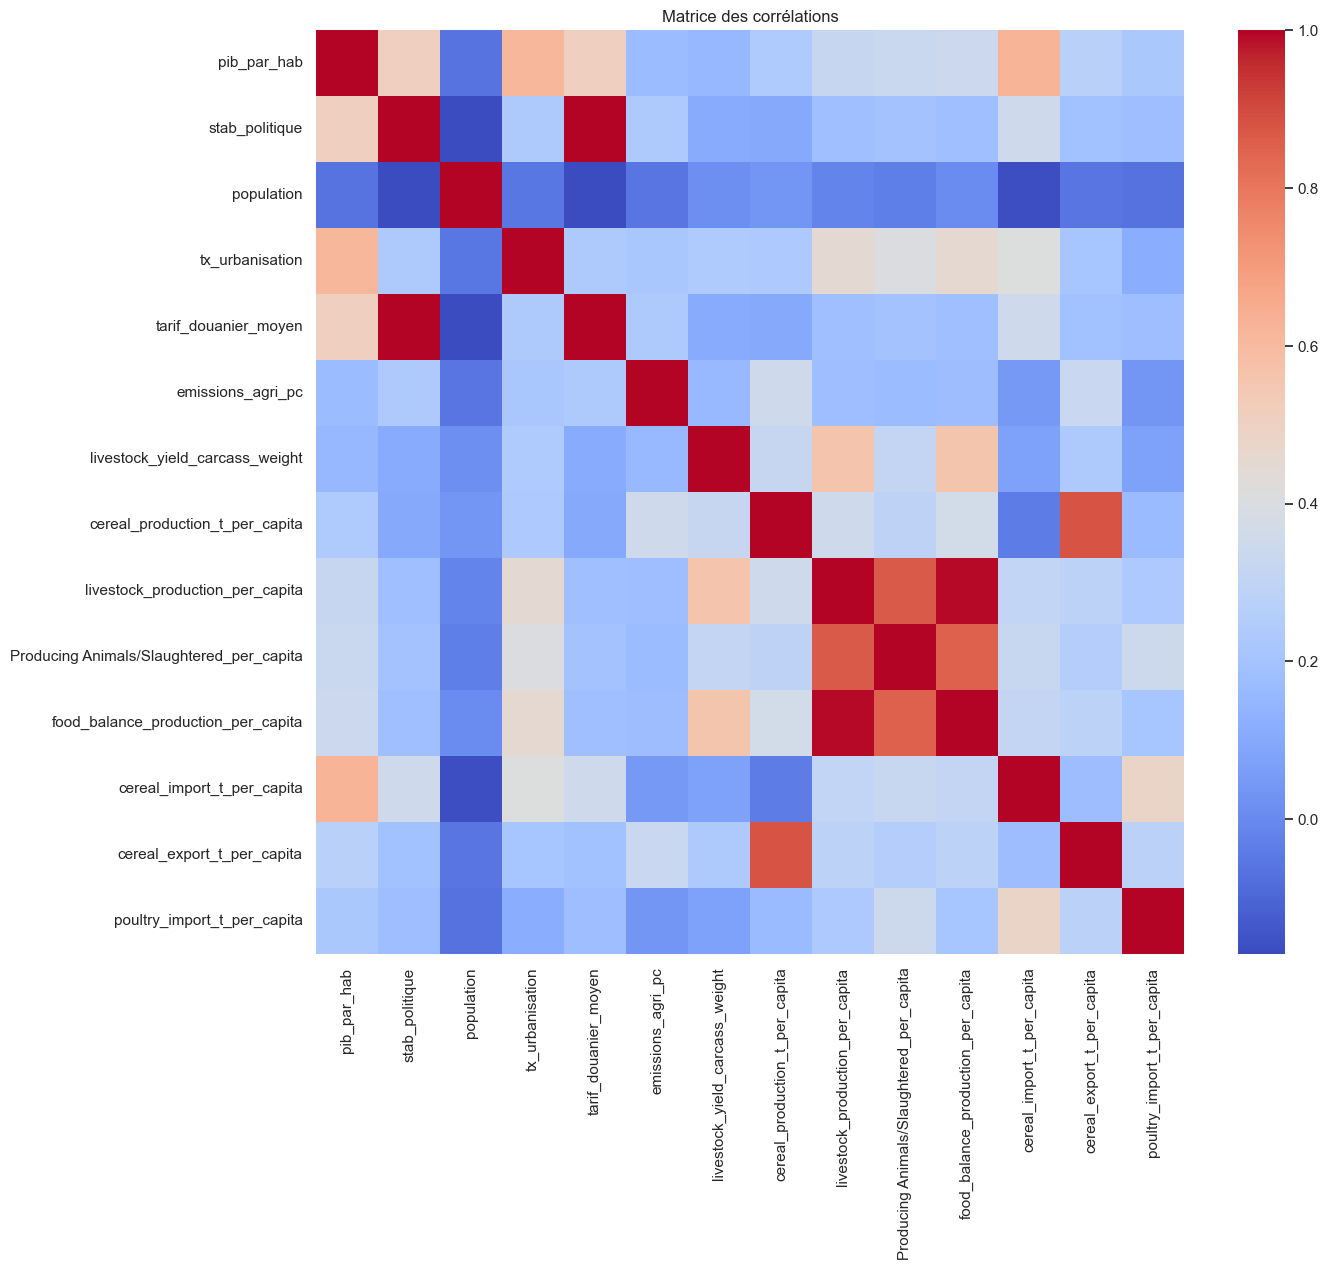

In [45]:
plt.figure(figsize=(14,12))
sns.heatmap(df_acp.corr(), cmap="coolwarm", annot=False)
plt.title("Matrice des corrélations")
plt.show()


In [46]:
#Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

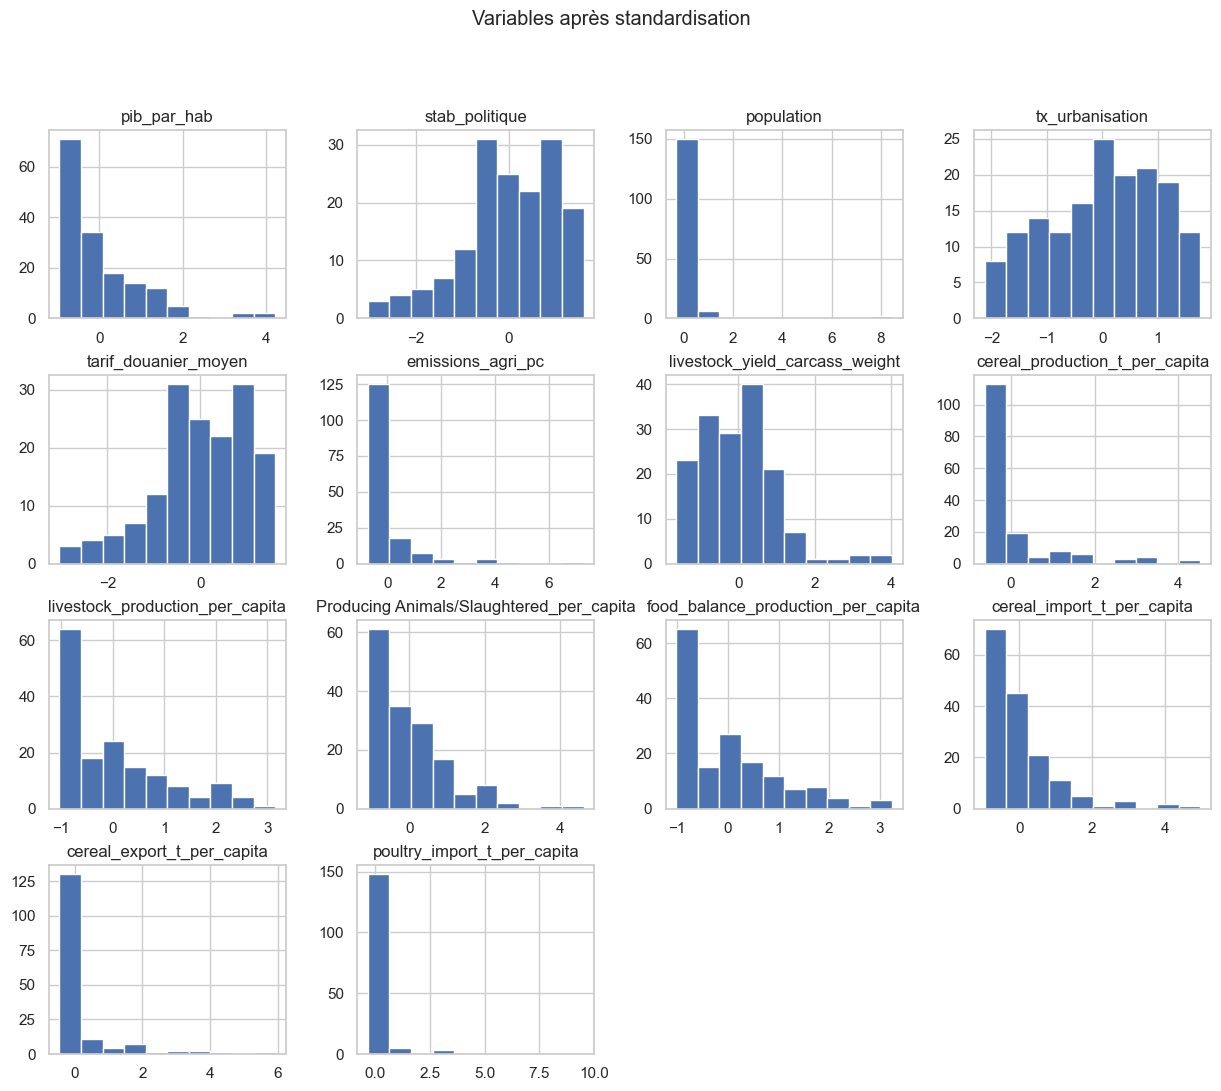

In [47]:
df_scaled = pd.DataFrame(X_scaled, columns=df_acp.columns)
df_scaled.hist(figsize=(15,12))
plt.suptitle("Variables après standardisation")
plt.show()


In [48]:
#ACP
pca = PCA(n_components=4)  # deux axes principaux
# pca = PCA()
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.34623117, 0.15517899, 0.11771301, 0.08505497])

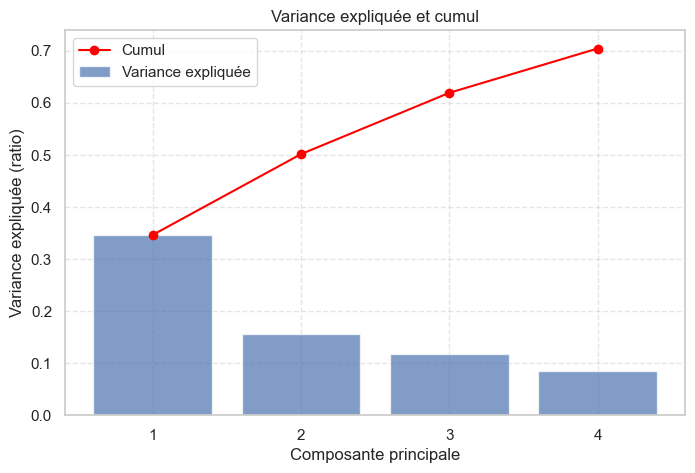

In [49]:
# Variance expliquée par composante
var_exp = pca.explained_variance_ratio_

# Cumul en pourcentage
cum_exp = np.cumsum(var_exp)

plt.figure(figsize=(8,5))

# Barres
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.7, label="Variance expliquée")

# Ligne rouge du cumul
plt.plot(range(1, len(cum_exp)+1), cum_exp, marker='o', color='red', label="Cumul")

plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée (ratio)")
plt.title("Variance expliquée et cumul")
plt.xticks(range(1, len(var_exp)+1))  # pour afficher tous les indices
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()


In [50]:
# Colonnes numériques réellement utilisées dans l'ACP
cols_acp = df_acp.columns.tolist()

print("Colonnes ACP retenues :", cols_acp)
print("Nombre :", len(cols_acp))

Colonnes ACP retenues : ['pib_par_hab', 'stab_politique', 'population', 'tx_urbanisation', 'tarif_douanier_moyen', 'emissions_agri_pc', 'livestock_yield_carcass_weight', 'cereal_production_t_per_capita', 'livestock_production_per_capita', 'Producing Animals/Slaughtered_per_capita', 'food_balance_production_per_capita', 'cereal_import_t_per_capita', 'cereal_export_t_per_capita', 'poultry_import_t_per_capita']
Nombre : 14


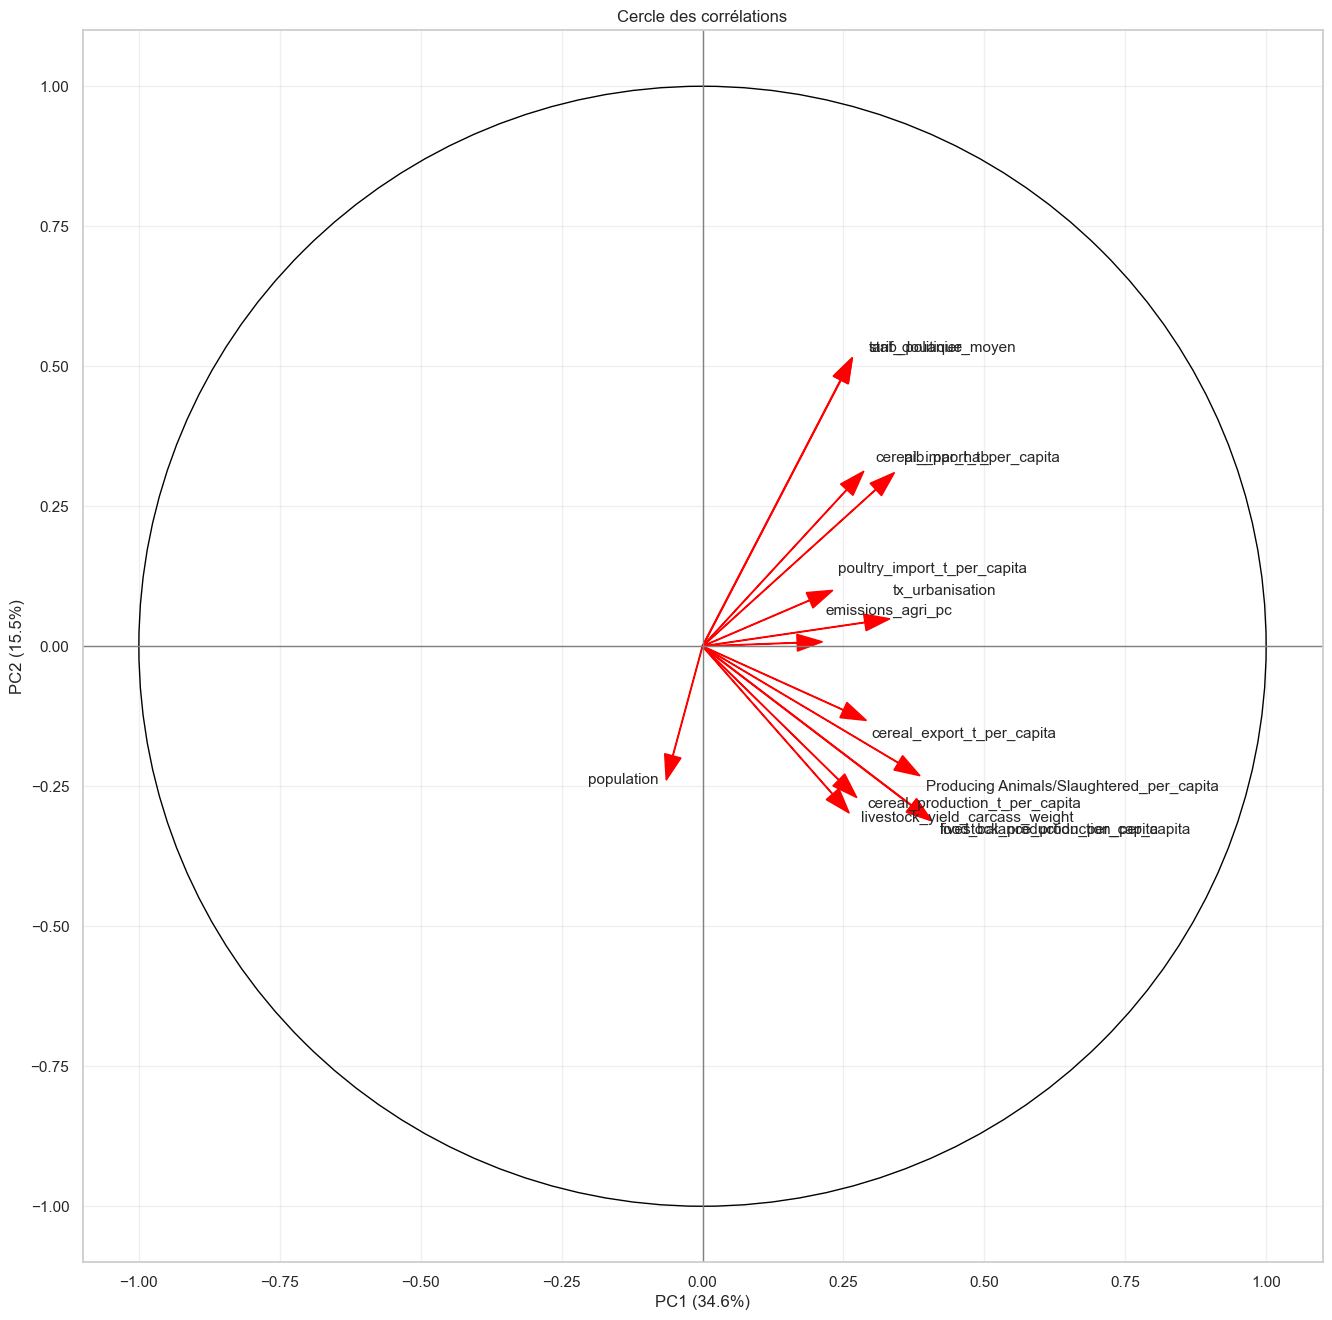

In [51]:
plt.figure(figsize=(16,16))

# Cercle unité
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1)
plt.gca().add_artist(circle)

for i, col in enumerate(cols_acp):
    x = pca.components_[0, i]
    y = pca.components_[1, i]
    
    # Flèche
    plt.arrow(0, 0, x, y, head_width=0.03, color='red')
    
    # Décalage dynamique : 
    # à droite → texte à droite, 
    # à gauche → texte à gauche, etc.
    dx = 0.05 if x >= 0 else -0.15
    dy = 0.05 if y >= 0 else -0.05
    
    plt.text(x + dx, y + dy, col, fontsize=11)

plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Cercle des corrélations")
plt.grid(alpha=0.3)
plt.show()


In [52]:
# Loadings PC1 et PC2
pc1 = pca.components_[0]
pc2 = pca.components_[1]

threshold = 0.3  # seuil que tu peux ajuster

important_vars = []

for i, col in enumerate(cols_acp):
    if abs(pc1[i]) > threshold or abs(pc2[i]) > threshold:
        important_vars.append({
            "Variable": col,
            "PC1_loading": pc1[i],
            "PC2_loading": pc2[i]
        })

df_imp = pd.DataFrame(important_vars).sort_values(
    by=["PC1_loading", "PC2_loading"], 
    key=np.abs, 
    ascending=False
)

print(df_imp)

                                   Variable  PC1_loading  PC2_loading
3           livestock_production_per_capita     0.370667    -0.284366
5        food_balance_production_per_capita     0.370607    -0.284020
4  Producing Animals/Slaughtered_per_capita     0.347310    -0.208141
0                               pib_par_hab     0.307471     0.279895
1                            stab_politique     0.245289     0.475481
2                      tarif_douanier_moyen     0.245289     0.475481


In [53]:
donnees_acp["PC1"]=X_pca[:,0]
donnees_acp["PC2"]=X_pca[:,1]

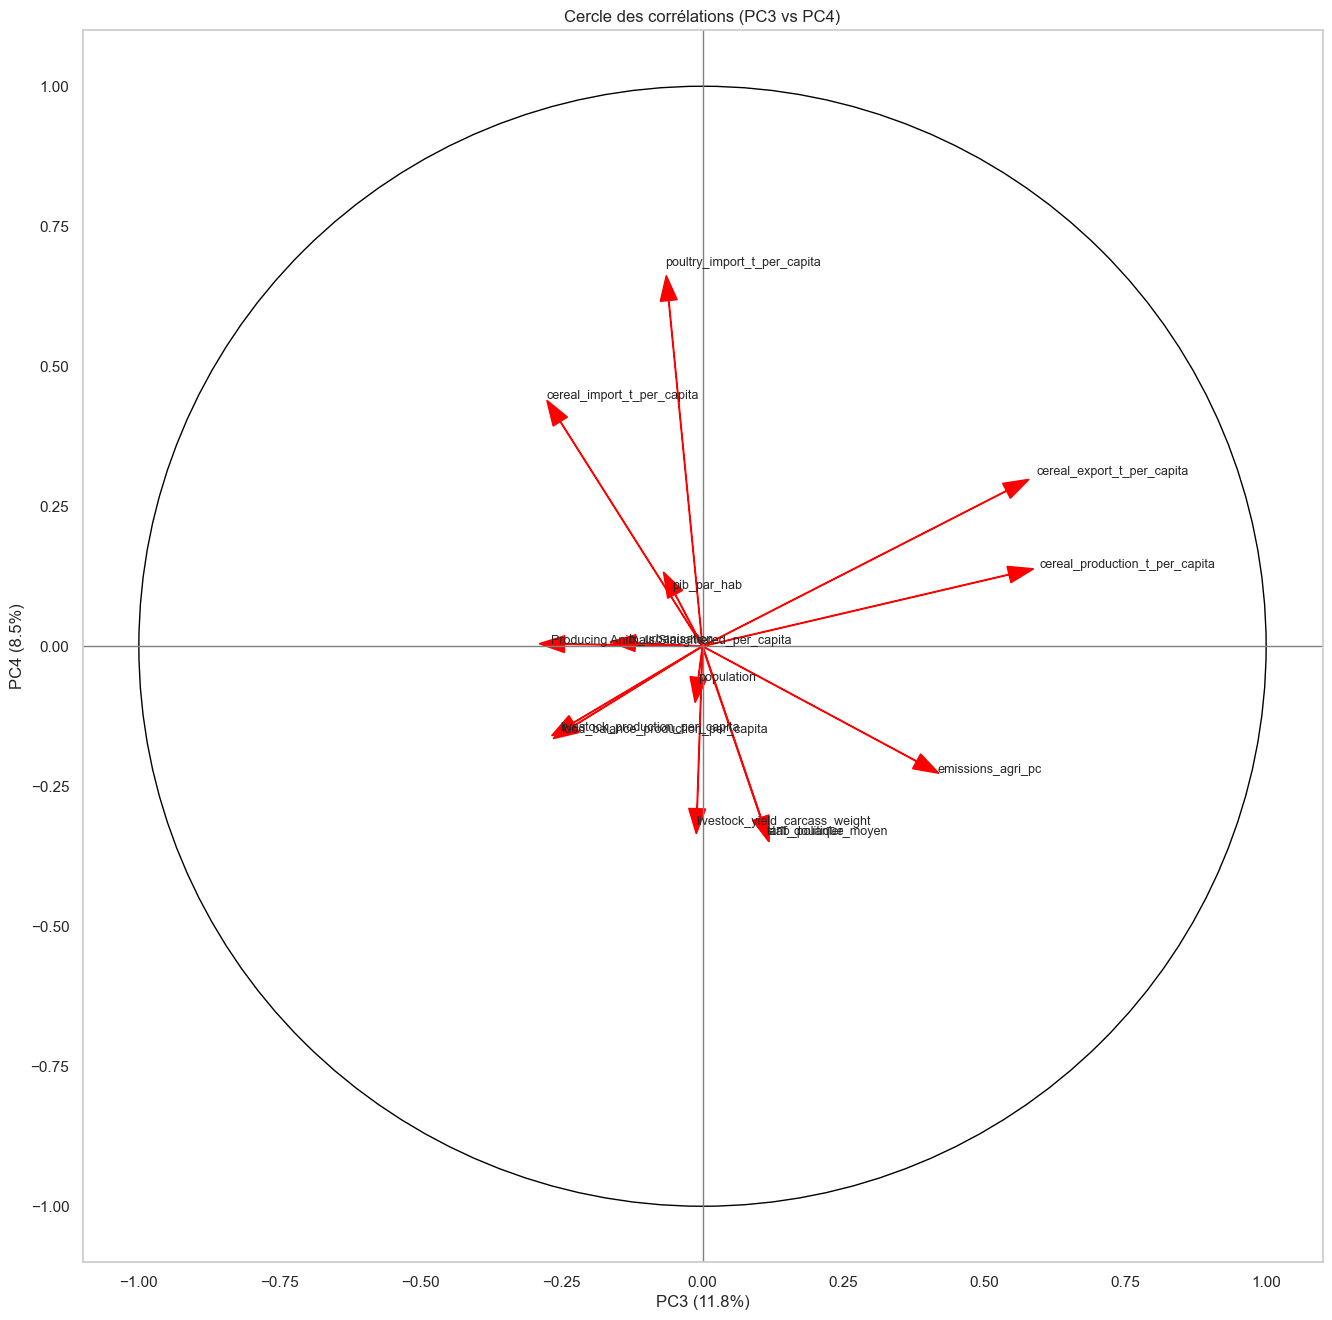

In [54]:
plt.figure(figsize=(16,16))

# Cercle unité
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1)
plt.gca().add_artist(circle)

# Vecteurs variables (PC3 = composante 2, PC4 = composante 3)
for i, col in enumerate(cols_acp):
    plt.arrow(0, 0, 
              pca.components_[2, i],   # PC3
              pca.components_[3, i],   # PC4
              head_width=0.03, 
              color='red')
    plt.text(pca.components_[2, i]*1.1, 
             pca.components_[3, i]*1.1, 
             col, fontsize=9)

# Axes
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("PC3 (%.1f%%)" % (pca.explained_variance_ratio_[2]*100))
plt.ylabel("PC4 (%.1f%%)" % (pca.explained_variance_ratio_[3]*100))

plt.title("Cercle des corrélations (PC3 vs PC4)")
plt.grid()
plt.show()

In [55]:
# Loadings PC3 et PC4
pc3 = pca.components_[2]
pc4 = pca.components_[3]

threshold = 0.35  # seuil recommandé car PC3 & PC4 ont des valeurs plus petites

important_vars_pc3_pc4 = []

for i, col in enumerate(cols_acp):
    if abs(pc3[i]) > threshold or abs(pc4[i]) > threshold:
        important_vars_pc3_pc4.append({
            "Variable": col,
            "PC3_loading": pc3[i],
            "PC4_loading": pc4[i]
        })

df_imp34 = pd.DataFrame(important_vars_pc3_pc4).sort_values(
    by=["PC3_loading", "PC4_loading"],
    key=np.abs,
    ascending=False
)

print("\n===== VARIABLES IMPORTANTES PC3–PC4 =====")
print(df_imp34)


===== VARIABLES IMPORTANTES PC3–PC4 =====
                         Variable  PC3_loading  PC4_loading
1  cereal_production_t_per_capita     0.543758     0.128002
3      cereal_export_t_per_capita     0.539357     0.277491
0               emissions_agri_pc     0.379836    -0.205426
2      cereal_import_t_per_capita    -0.252274     0.401224
4     poultry_import_t_per_capita    -0.059924     0.617398


In [56]:
donnees_acp["PC3"]=X_pca[:,2]
donnees_acp["PC4"]=X_pca[:,3]

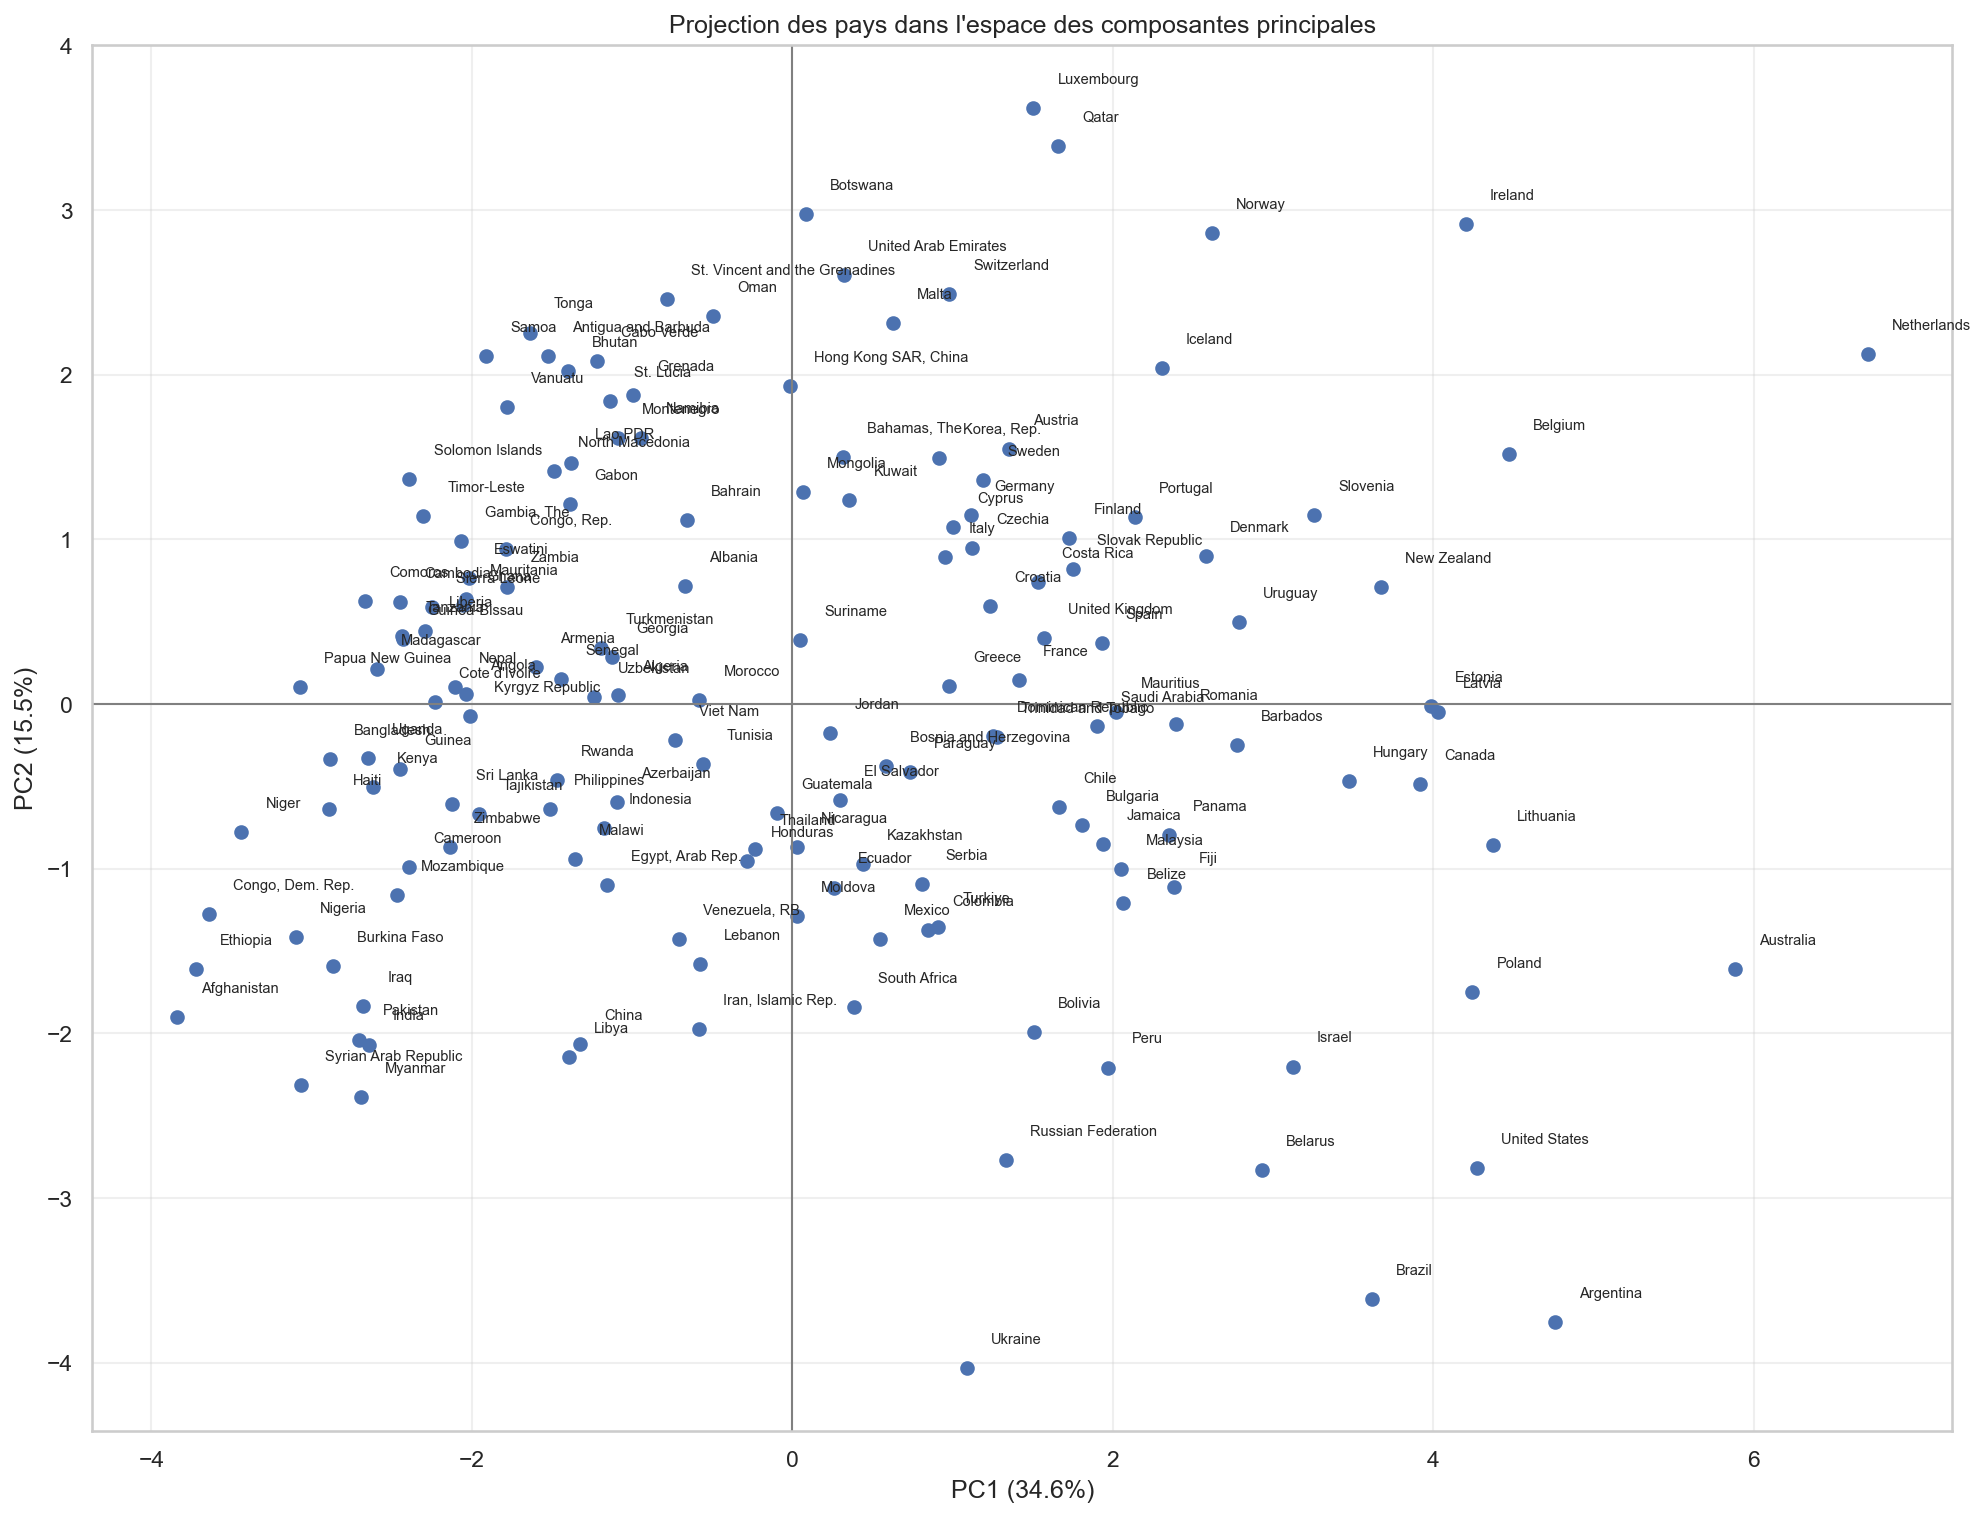

In [57]:
plt.figure(figsize=(16,12),dpi=150)
plt.scatter(donnees_acp["PC1"], donnees_acp["PC2"])

# Labels décalés
for i in range(donnees_acp.shape[0]):
    x = donnees_acp["PC1"].iloc[i]
    y = donnees_acp["PC2"].iloc[i]
    country = donnees_acp["Country"].iloc[i]
    plt.text(x + 0.15, y + 0.15, country, fontsize=7)
    
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlabel("PC1 (%.1f%%)" % (pca.explained_variance_ratio_[0]*100))
plt.ylabel("PC2 (%.1f%%)" % (pca.explained_variance_ratio_[1]*100))
plt.title("Projection des pays dans l'espace des composantes principales")
plt.grid(alpha=0.3)
plt.show()

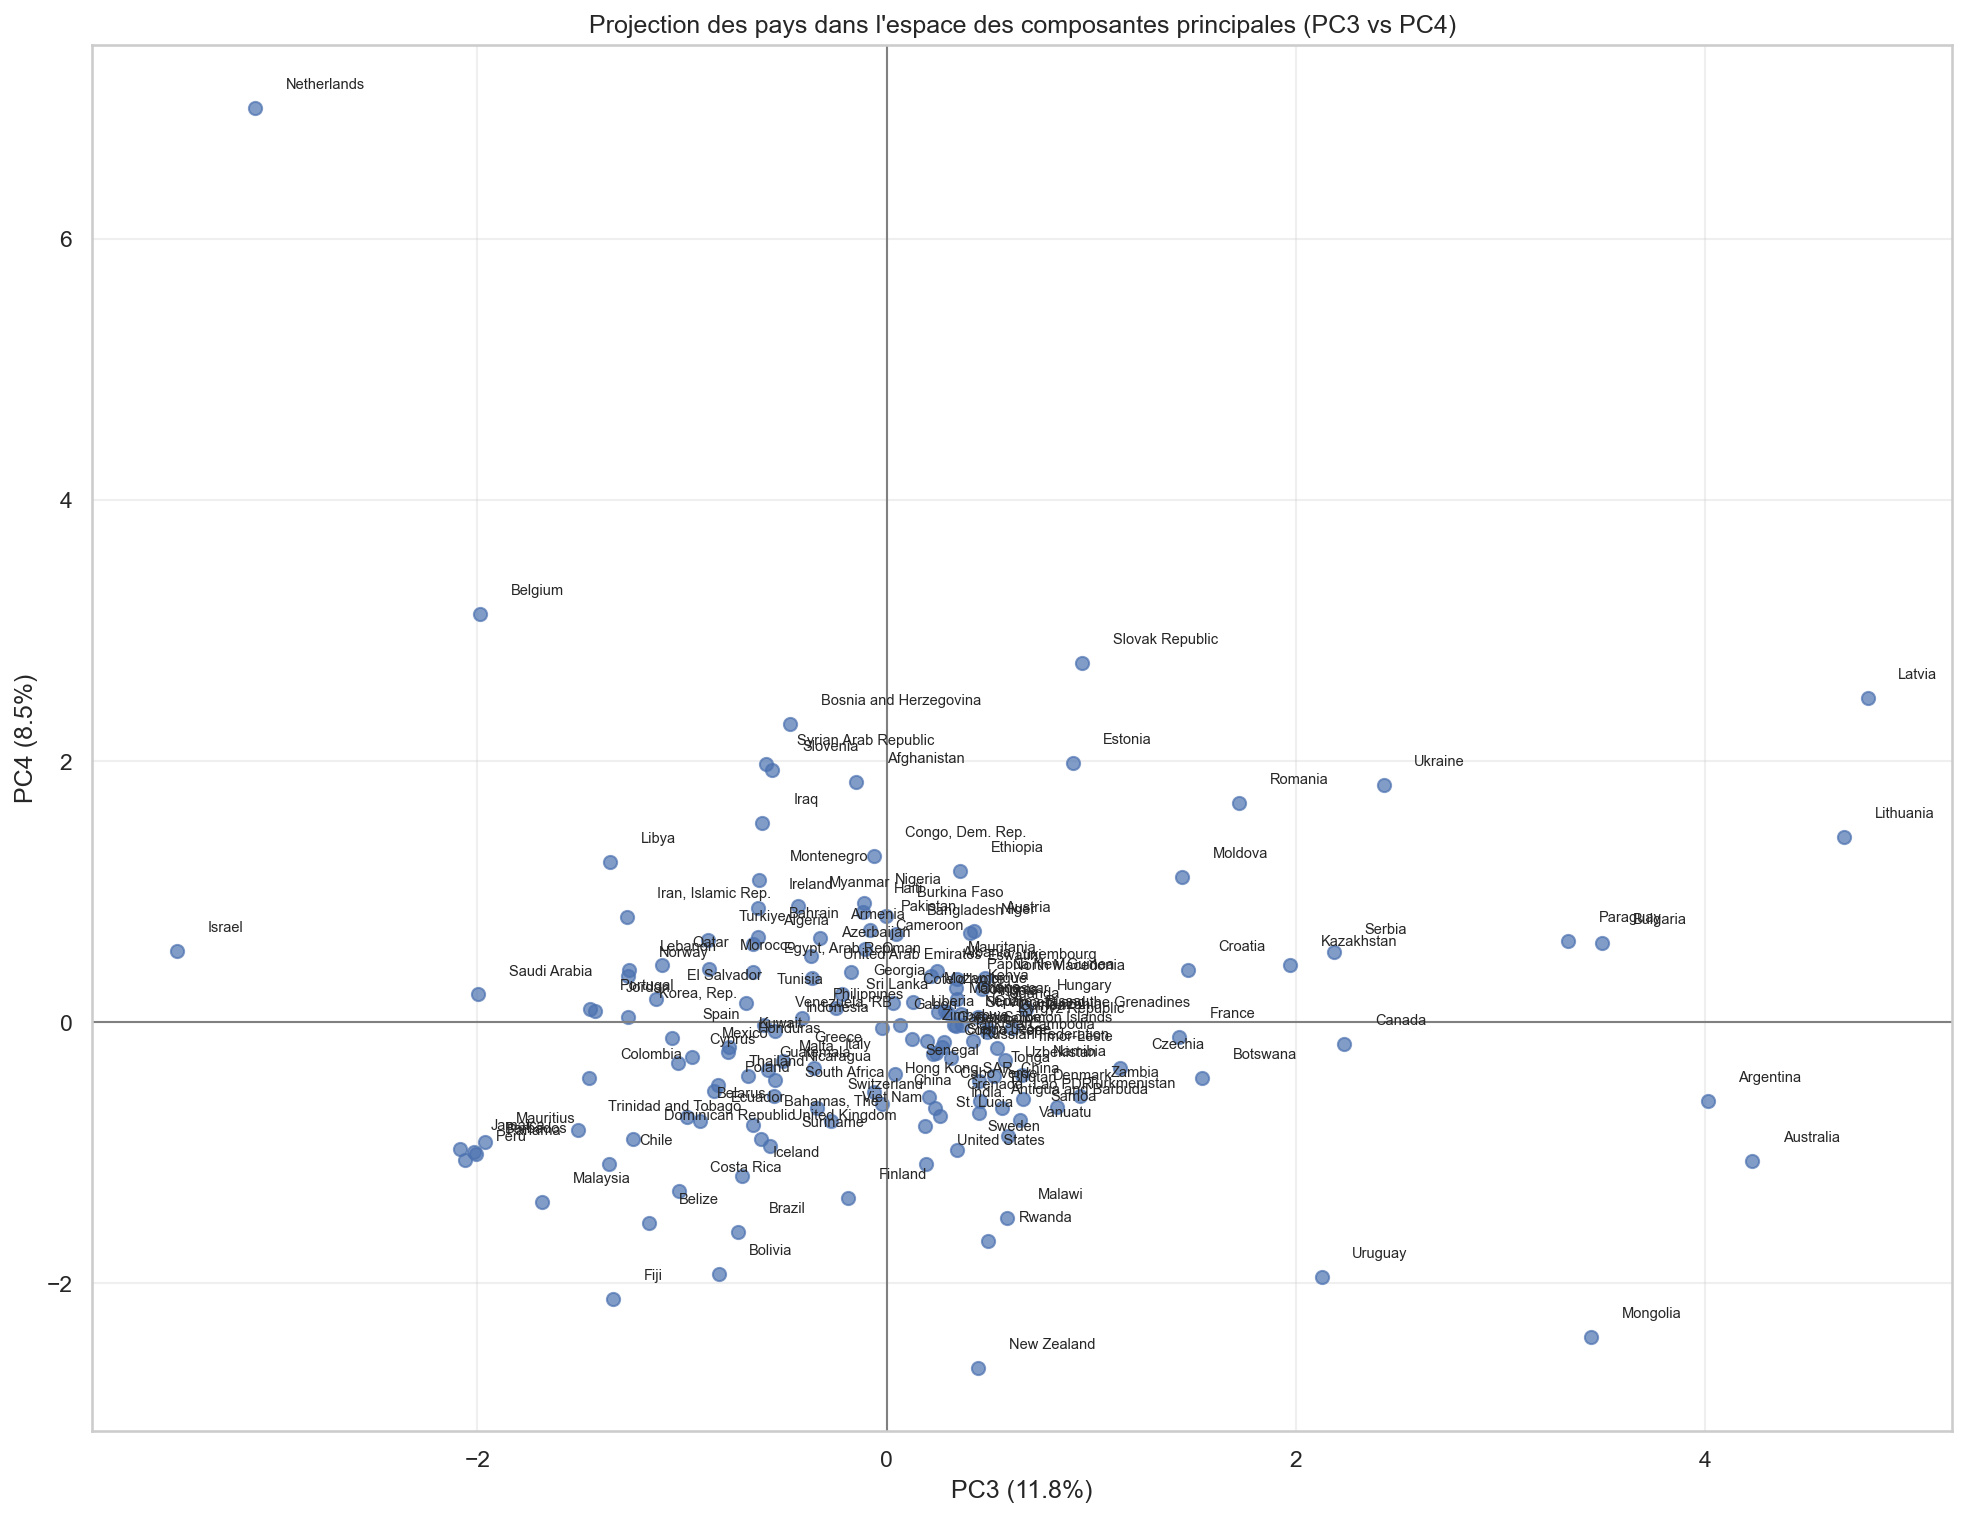

In [58]:
plt.figure(figsize=(16,12), dpi=150)

plt.scatter(donnees_acp["PC3"], donnees_acp["PC4"], s=40, alpha=0.7)

# Labels décalés
for i in range(donnees_acp.shape[0]):
    x = donnees_acp["PC3"].iloc[i]
    y = donnees_acp["PC4"].iloc[i]
    country = donnees_acp["Country"].iloc[i]
    plt.text(x + 0.15, y + 0.15, country, fontsize=7)

plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

plt.xlabel("PC3 (%.1f%%)" % (pca.explained_variance_ratio_[2]*100))
plt.ylabel("PC4 (%.1f%%)" % (pca.explained_variance_ratio_[3]*100))
plt.title("Projection des pays dans l'espace des composantes principales (PC3 vs PC4)")
plt.grid(alpha=0.3)
plt.show()


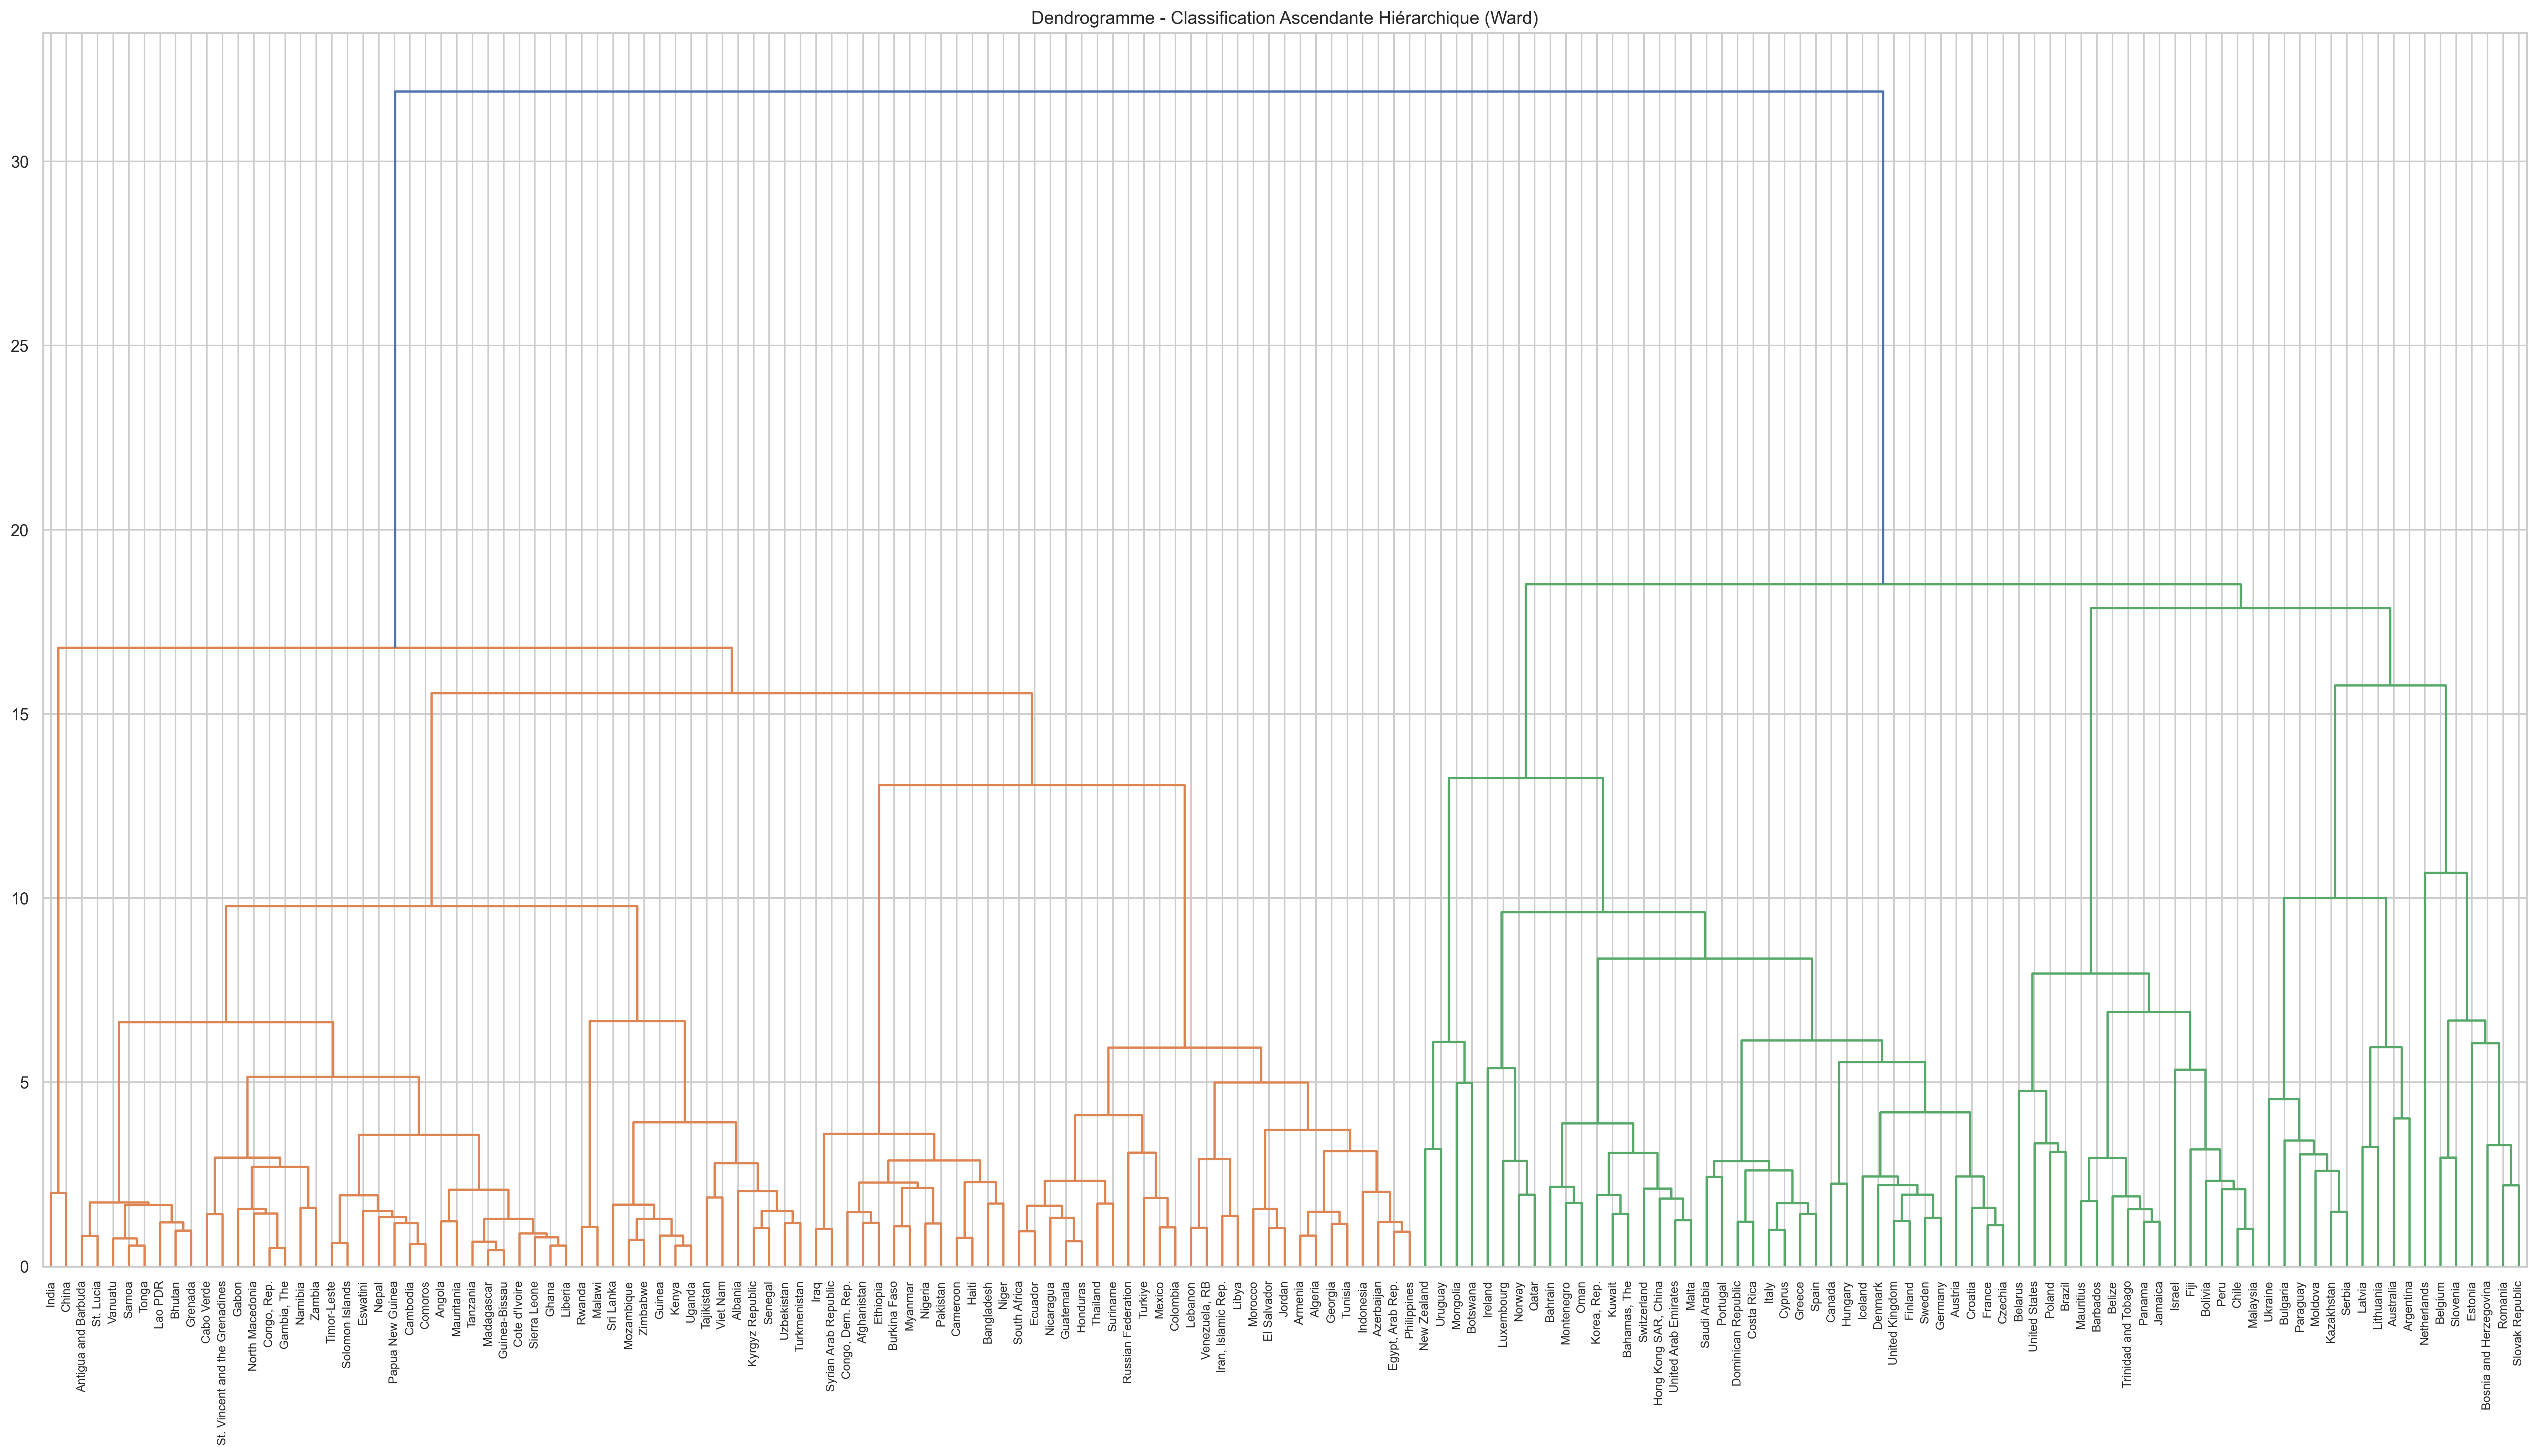

In [59]:
# CAH avec méthode Ward 
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(30, 15),dpi=300)
dendrogram(
    Z,
    labels=donnees_acp["Country"].values,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Dendrogramme - Classification Ascendante Hiérarchique (Ward)")
plt.show()

In [60]:
# Création du dendrogramme interactif
fig = ff.create_dendrogram(
    X_scaled,
    labels=donnees_acp["Country"].values,
    orientation='bottom',
    linkagefun=lambda x: linkage(x, method='ward')
)

# Taille du graphique
fig.update_layout(
    width=1400,
    height=800,
    title="Dendrogramme interactif - CAH (Ward)",
    xaxis=dict(tickfont=dict(size=10)),
)

fig.show()

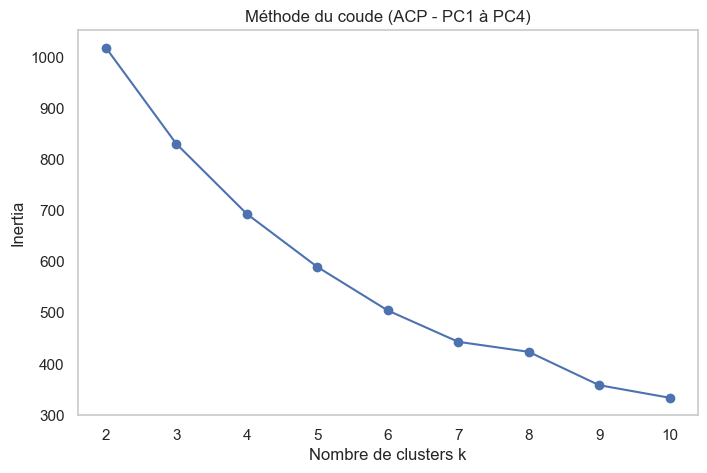

In [61]:
X_kmeans = donnees_acp[["PC1", "PC2", "PC3", "PC4"]].values

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_kmeans)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertia")
plt.title("Méthode du coude (ACP - PC1 à PC4)")
plt.grid()
plt.show()


In [62]:
k = 7
kmeans = KMeans(n_clusters=k, random_state=0)
donnees_acp["cluster"] = kmeans.fit_predict(X_kmeans)

In [63]:
donnees_acp.head()
donnees_acp["cluster_str"]=donnees_acp["cluster"].astype(str)
donnees_acp.head()

,Country,taux_remplissage,nb_colonnes_remplies,ISO3,indicateur_perf_logistique,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,...,poultry_import_t,cereal_production_t,cereal_import_t,cereal_export_t,PC1,PC2,PC3,PC4,cluster,cluster_str
0,Bosnia and Herzegovina,100.0,26,BIH,3.0,21117.283077,-0.483194,3204802.0,49.841,-0.483194,...,29708.0,1268.0,773.0,100.0,0.581466,-0.375304,-0.472503,2.286672,6,6
1,Switzerland,100.0,26,CHE,4.1,91326.131705,1.159745,8777088.0,74.092,1.159745,...,309.0,612.0,1606.0,184.0,0.978618,2.488822,-0.339443,-0.657536,3,3
2,Belgium,100.0,26,BEL,4.0,68157.834786,0.581982,11680210.0,98.153,0.581982,...,109384.0,2352.0,9771.0,3460.0,4.470129,1.515150,-1.988755,3.126261,5,5
3,Cameroon,100.0,26,CMR,2.1,5188.977509,-1.379629,27632771.0,58.733,-1.379629,...,1039.0,2201.0,1020.0,22.0,-2.394224,-0.992609,-0.106371,0.560302,0,0
4,Canada,100.0,26,CAN,4.0,63578.320195,0.780682,38935934.0,81.752,0.780682,...,31890.0,48895.0,8213.0,22936.0,3.920043,-0.483645,2.237082,-0.166528,2,2


In [64]:
fig = px.scatter(
    donnees_acp,
    x="PC1",
    y="PC2",
    color="cluster_str",
    hover_name="Country",
    hover_data={"PC1":":.2f", "PC2":":.2f"},
    title="Clustering des pays (ACP + K-means) – Graphique interactif"
)

# Ajout des lignes verticales/horizontales
fig.add_shape(type="line", x0=0, y0=donnees_acp["PC2"].min(),
              x1=0, y1=donnees_acp["PC2"].max(),
              line=dict(color="grey", width=1))

fig.add_shape(type="line", x0=donnees_acp["PC1"].min(), y0=0,
              x1=donnees_acp["PC1"].max(), y1=0,
              line=dict(color="grey", width=1))

fig.update_layout(
    width=900,
    height=700,
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
)

fig.show()

In [65]:
fig = px.scatter(
    donnees_acp,
    x="PC3",
    y="PC4",
    color="cluster_str",
    hover_name="Country",
    hover_data={"PC3":":.2f", "PC4":":.2f"},
    title="Clustering des pays (ACP + K-means) – Plan PC3–PC4"
)

# Lignes verticales et horizontales
fig.add_shape(type="line", 
              x0=0, y0=donnees_acp["PC4"].min(),
              x1=0, y1=donnees_acp["PC4"].max(),
              line=dict(color="grey", width=1))

fig.add_shape(type="line",
              x0=donnees_acp["PC3"].min(), y0=0,
              x1=donnees_acp["PC3"].max(), y1=0,
              line=dict(color="grey", width=1))

fig.update_layout(
    width=900,
    height=700,
    xaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)",
    yaxis_title=f"PC4 ({pca.explained_variance_ratio_[3]*100:.1f}%)",
)

fig.show()

In [66]:
donnees_acp["cluster"].value_counts()

cluster
0    34
4    34
6    26
3    26
1    20
2    13
5     6
Name: count, dtype: int64

In [67]:
donnees_originales = df_acp.copy()   # ou le nom de ton dataset initial
donnees_originales["cluster"] = donnees_acp["cluster"]


In [68]:
caract_vars = donnees_originales.groupby("cluster").mean(numeric_only=True)
caract_vars


,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,emissions_agri_pc,livestock_yield_carcass_weight,cereal_production_t_per_capita,livestock_production_per_capita,Producing Animals/Slaughtered_per_capita,food_balance_production_per_capita,cereal_import_t_per_capita,cereal_export_t_per_capita,poultry_import_t_per_capita
cluster,,,,,,,,,,,,,,
0,5471.234915,-1.097235,9.081952e+07,39.025647,-1.097235,206.818644,1199.941176,0.000071,0.003641,0.003037,0.000004,0.000043,0.000003,0.000075
1,33136.076561,0.110084,4.519824e+07,70.318050,0.110084,436.091608,1975.550000,0.000216,0.048170,0.026038,0.000050,0.000180,0.000061,0.000507
2,38293.012036,0.212163,1.754516e+07,72.637231,0.212163,886.235372,1885.307692,0.001156,0.027607,0.014430,0.000030,0.000160,0.000793,0.001636
3,66311.355336,0.719670,1.890790e+07,82.226269,0.719670,270.840530,1498.884615,0.000195,0.017082,0.011316,0.000019,0.000256,0.000100,0.000509
4,14650.247148,0.336247,6.045484e+06,49.413765,0.336247,388.206422,1103.676471,0.000052,0.002659,0.002567,0.000003,0.000125,0.000019,0.000280
5,70231.951293,0.679333,7.247783e+06,72.415167,0.679333,603.241425,1537.666667,0.000292,0.030724,0.027202,0.000030,0.000641,0.000388,0.010649
6,16586.919839,-0.668056,1.005878e+08,66.524269,-0.668056,207.305820,1540.769231,0.000142,0.020566,0.013897,0.000022,0.000157,0.000037,0.000561


In [69]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_acp)  # df_acp = variables utilisées dans le PCA
scaled_df = pd.DataFrame(scaled, columns=df_acp.columns)
scaled_df["cluster"] = donnees_acp["cluster"]

caract_std = scaled_df.groupby("cluster").mean()
caract_std

,pib_par_hab,stab_politique,population,tx_urbanisation,tarif_douanier_moyen,emissions_agri_pc,livestock_yield_carcass_weight,cereal_production_t_per_capita,livestock_production_per_capita,Producing Animals/Slaughtered_per_capita,food_balance_production_per_capita,cereal_import_t_per_capita,cereal_export_t_per_capita,poultry_import_t_per_capita
cluster,,,,,,,,,,,,,,
0,-0.815560,-1.128627,0.264508,-0.975571,-1.128627,-0.312197,-0.450207,-0.410861,-0.807191,-0.787120,-0.801246,-0.701398,-0.437520,-0.286856
1,0.194557,0.234289,-0.015001,0.429532,0.234289,0.169214,0.944449,0.004314,1.887569,1.544171,1.852418,0.096940,-0.210394,-0.126804
2,0.382850,0.349525,-0.184424,0.533669,0.349525,1.114392,0.782180,2.705683,0.643157,0.367636,0.674995,-0.018738,2.668396,0.290467
3,1.405874,0.922439,-0.176075,0.964239,0.922439,-0.177768,0.087336,-0.055031,0.006259,0.052037,0.046574,0.537340,-0.055309,-0.126257
4,-0.480410,0.489601,-0.254880,-0.509120,0.489601,0.068668,-0.623305,-0.465305,-0.866606,-0.834725,-0.871949,-0.222470,-0.374879,-0.210759
5,1.549025,0.876904,-0.247514,0.523698,0.876904,0.520183,0.157072,0.222935,0.831792,1.662198,0.700733,2.784535,1.075363,3.623420
6,-0.409697,-0.644136,0.324355,0.259182,-0.644136,-0.311174,0.162651,-0.206819,0.217046,0.313611,0.217307,-0.036991,-0.302839,-0.106881


In [70]:
caract_pca = donnees_acp.groupby("cluster")[["PC1","PC2","PC3","PC4"]].mean()
caract_pca

,PC1,PC2,PC3,PC4
cluster,,,,
0,-2.567956,-0.728650,0.099653,0.378228
1,2.417262,-1.294464,-1.315045,-1.042023
2,2.808195,-1.083488,2.914898,0.455643
3,1.286166,1.455424,-0.271414,-0.300222
4,-1.410529,1.266441,0.433262,-0.310906
5,4.063143,1.418363,-0.732541,2.945739
6,-0.284710,-0.948519,-0.702304,0.106135


In [71]:
import scipy.stats as stats

anova_results = []

for col in df_acp.columns:
    groups = [df_acp[col][donnees_acp["cluster"] == k] for k in sorted(donnees_acp.cluster.unique())]
    f, p = stats.f_oneway(*groups)
    anova_results.append({"Variable": col, "F": f, "p_value": p})

df_anova = pd.DataFrame(anova_results).sort_values("F", ascending=False)
df_anova


,Variable,F,p_value
8,livestock_production_per_capita,112.141478,3.011961e-53
10,food_balance_production_per_capita,98.453719,8.296071e-50
12,cereal_export_t_per_capita,64.454612,2.692203e-39
9,Producing Animals/Slaughtered_per_capita,63.012181,9.102599e-39
7,cereal_production_t_per_capita,56.469364,2.957905e-36
0,pib_par_hab,46.948511,3.185835e-32
1,stab_politique,34.491401,4.417511e-26
4,tarif_douanier_moyen,34.491401,4.417511e-26
13,poultry_import_t_per_capita,29.256173,4.035139e-23
3,tx_urbanisation,23.273051,2.198247e-19


In [72]:

# caract_std = moyenne des clusters sur variables standardisées
# obtenu dans l'étape précédente
df_radar = caract_std.copy()
df_radar["cluster"] = df_radar.index

# Convertir en format long
df_long = df_radar.melt(id_vars="cluster",
                        var_name="Variable",
                        value_name="Valeur")

# Radar plot
fig = px.line_polar(
    df_long,
    r="Valeur",
    theta="Variable",
    color="cluster",
    line_close=True,
    markers=True,
    title="Radar plot – Profil standardisé des clusters"
)

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[df_long["Valeur"].min()-0.5,
                                             df_long["Valeur"].max()+0.5])
    ),
    width=850,
    height=800
)

fig.show()


# Choix du cluster 2
* Niveau de développement économique élevé.

* Pouvoir d’achat adapté à des produits premium comme le poulet biologique.

* Sensibilité forte aux questions de qualité, traçabilité et normes environnementales.

* Marchés déjà familiers avec les labels et certifications bio.

* Infrastructures logistiques fiables pour l’importation de produits agroalimentaires.

* Réglementations sanitaires strictes mais maîtrisées, facilitant l’intégration de produits bio importés.

* Demande établie et croissante pour des produits durables et respectueux du bien-être animal.

* Environnement commercial favorable à l’introduction de viande bio française.

In [73]:
pays_cluster_2 = donnees_acp.loc[donnees_acp["cluster"] == 5, "Country"]

print("Pays du cluster 5 :")
for p in pays_cluster_2:
    print("-", p)


Pays du cluster 5 :
- Belgium
- Slovenia
- Netherlands
- Ireland
- Estonia
- Slovak Republic
